In [1]:
!du -sh ~

24G	/home/s/segev


In [4]:
!quota -s

In [5]:
!df -h ~

Filesystem        Size  Used Avail Use% Mounted on
sdfhomenfs:/home   30G   25G  5.8G  81% /home


In [ ]:
#!/usr/bin/env python3
"""
Complete analysis of scheduler performance vs best sky for all combinations.

Analyzes every scheduler night against every chronograf night, computing:
- Best possible pointing (lowest attenuation above horizon)
- Actual scheduler pointing attenuation
- Difference (gain = actual - best, positive = worse performance)

Saves results to CSV with periodic progress updates.
"""

import io
import os
import sqlite3
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
from datetime import datetime, timedelta

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"
CHRONOGRAF_CSV = "all_chronograf_data.csv"
OUTPUT_CSV = "complete_scheduler_analysis.csv"

NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0

# Time matching window (hours) - how close observations need to be
TIME_WINDOW_HOURS = 0.5  # 30 minutes

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    """Transform https S3 paths to ResourcePath style if needed."""
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    """Fetch and read HEALPix cloud map from URL."""
    url = str(url).strip()
    if url.startswith("s3://") or url.startswith("http://") or url.startswith("https://"):
        rp = ResourcePath(url)
        with rp.open("rb") as fd:
            data = fd.read()
        bio = io.BytesIO(data)
    else:
        bio = open(url, "rb")
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None,
                     observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                     observer_height_m=RUBIN_HEIGHT_M):
    """Convert HEALPix map pixels to alt/az arrays."""
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime,
                   observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                   observer_height_m=RUBIN_HEIGHT_M):
    """Convert RA/Dec to Alt/Az at given time."""
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_best_pointing(mp, nside, obstime):
    """Find the alt/az of pixel with lowest attenuation above horizon."""
    az_deg, alt_deg, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Only consider points above horizon
    valid_mask = (alt_deg > 0) & (~np.isnan(vals))
    if not np.any(valid_mask):
        return None, None, None
    
    valid_vals = vals[valid_mask]
    valid_az = az_deg[valid_mask]
    valid_alt = alt_deg[valid_mask]
    
    min_idx = np.nanargmin(valid_vals)
    return valid_az[min_idx], valid_alt[min_idx], valid_vals[min_idx]

def get_attenuation_at_pointing(mp, nside, ra_deg, dec_deg, obstime):
    """Get cloud attenuation value at a specific RA/Dec pointing."""
    # Convert pointing to alt/az
    actual_alt, actual_az = radec_to_altaz(ra_deg, dec_deg, obstime)
    
    if actual_alt <= 0:
        return None, actual_alt, actual_az
    
    # Get all map values in alt/az
    az_arr, alt_arr, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Find nearest pixel
    d_az = np.minimum(np.abs(az_arr - actual_az), 360.0 - np.abs(az_arr - actual_az))
    distances = np.sqrt(d_az**2 + (alt_arr - actual_alt)**2)
    
    if np.all(np.isnan(vals)):
        return None, actual_alt, actual_az
    
    nearest_idx = np.nanargmin(distances)
    actual_val = vals[nearest_idx]
    
    if np.isnan(actual_val):
        return None, actual_alt, actual_az
    
    return actual_val, actual_alt, actual_az

def time_match_hours(mjd, datetime_utc):
    """Calculate time difference in hours between MJD and datetime."""
    mjd_time = Time(mjd, format='mjd').to_datetime()
    
    # Calculate hour difference
    mjd_hour = mjd_time.hour + mjd_time.minute / 60.0 + mjd_time.second / 3600.0
    dt_hour = datetime_utc.hour + datetime_utc.minute / 60.0 + datetime_utc.second / 3600.0
    
    diff = abs(mjd_hour - dt_hour)
    # Handle wrap around midnight
    if diff > 12:
        diff = 24 - diff
    
    return diff

# ---------------- DATA LOADING ----------------
def load_scheduler_nights(db_file):
    """Load all scheduler nights and their observations."""
    conn = sqlite3.connect(db_file)
    
    # First, check what tables exist
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print(f"  Available tables: {[t[0] for t in tables]}")
    
    # Try common table names
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            print(f"  Using table: {table_name}")
            break
    
    if table_name is None:
        # Use the first table
        table_name = tables[0][0]
        print(f"  Using first available table: {table_name}")
    
    # Check columns
    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()
    print(f"  Available columns: {[col[1] for col in columns]}")
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    # Find the night column
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    if night_col is None:
        raise RuntimeError(f"Could not find 'night' column. Available columns: {obs_df.columns.tolist()}")
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    # Check for required columns
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    missing = []
    for req in required:
        found = False
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                found = True
                break
        if not found:
            missing.append(req)
    
    if missing:
        print(f"  WARNING: Missing columns: {missing}")
        print(f"  Available columns: {obs_df.columns.tolist()}")
    
    scheduler_nights = {}
    for night in obs_df['night'].unique():
        night_obs = obs_df[obs_df['night'] == night].copy()
        scheduler_nights[int(night)] = night_obs
    
    return scheduler_nights

def load_chronograf_nights(csv_file):
    """Load all chronograf nights and their cloud maps."""
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    # Find URL column
    url_cols = [c for c in df.columns if c.lower() not in ['time', 'timestamp']]
    if len(url_cols) == 0:
        raise RuntimeError("No URL column found in chronograf CSV.")
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    
    # Parse times with UTC enforcement to handle mixed timezones
    df['time'] = pd.to_datetime(df['time'], errors='coerce', utc=True)
    
    # Remove any rows where time parsing failed
    df = df.dropna(subset=['time']).copy()
    
    # Ensure all times are in UTC
    if df['time'].dt.tz is None:
        df['time'] = df['time'].dt.tz_localize('UTC')
    else:
        df['time'] = df['time'].dt.tz_convert('UTC')
    
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    # Group by date
    df['date'] = df['time'].dt.date
    chronograf_nights = {}
    
    for date in df['date'].unique():
        date_df = df[df['date'] == date].sort_values('time').reset_index(drop=True)
        chronograf_nights[date] = date_df
    
    return chronograf_nights

# ---------------- MAIN ANALYSIS ----------------
def analyze_all_combinations():
    """Analyze all scheduler night vs chronograf night combinations."""
    
    print("="*80)
    print("LOADING DATA")
    print("="*80)
    
    print(f"\nLoading scheduler nights from {DB_FILE}...")
    scheduler_nights = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(scheduler_nights)} scheduler nights")
    
    print(f"\nLoading chronograf nights from {CHRONOGRAF_CSV}...")
    chronograf_nights = load_chronograf_nights(CHRONOGRAF_CSV)
    print(f"✓ Loaded {len(chronograf_nights)} chronograf nights")
    
    # Calculate total combinations
    total_combinations = len(scheduler_nights) * len(chronograf_nights)
    print(f"\n{'='*80}")
    print(f"TOTAL COMBINATIONS TO ANALYZE: {total_combinations}")
    print(f"{'='*80}\n")
    
    results = []
    combo_count = 0
    
    # Iterate through all combinations
    for sched_night, sched_obs in sorted(scheduler_nights.items()):
        for chron_date, chron_df in sorted(chronograf_nights.items()):
            combo_count += 1
            
            print(f"\n[{combo_count}/{total_combinations}] Analyzing Scheduler Night {sched_night} vs Chronograf {chron_date}")
            print(f"  Scheduler observations: {len(sched_obs)}")
            print(f"  Chronograf maps: {len(chron_df)}")
            
            # Process each chronograf map
            maps_processed = 0
            matches_found = 0
            
            for idx, chron_row in chron_df.iterrows():
                maps_processed += 1
                
                # Load cloud map
                try:
                    cloud_map = fetch_map_resourcepath(chron_row[chron_df.columns[1]])
                    map_time = chron_row['time'].to_pydatetime()
                except Exception as e:
                    continue
                
                # Find best possible pointing
                best_az, best_alt, best_atten = find_best_pointing(
                    cloud_map, NSIDE_EXPECTED, map_time)
                
                if best_atten is None:
                    continue
                
                # Find matching scheduler observation(s)
                for _, obs in sched_obs.iterrows():
                    time_diff = time_match_hours(obs['observationStartMJD'], map_time)
                    
                    if time_diff <= TIME_WINDOW_HOURS:
                        # Get actual pointing attenuation
                        actual_atten, actual_alt, actual_az = get_attenuation_at_pointing(
                            cloud_map, NSIDE_EXPECTED,
                            obs['fieldRA'], obs['fieldDec'], map_time)
                        
                        if actual_atten is not None:
                            matches_found += 1
                            difference = actual_atten - best_atten
                            
                            results.append({
                                'scheduler_night': sched_night,
                                'chronograf_date': str(chron_date),
                                'map_time_utc': map_time.isoformat(),
                                'obs_mjd': obs['observationStartMJD'],
                                'time_diff_hours': time_diff,
                                'best_attenuation': best_atten,
                                'best_az': best_az,
                                'best_alt': best_alt,
                                'actual_attenuation': actual_atten,
                                'actual_az': actual_az,
                                'actual_alt': actual_alt,
                                'difference': difference,
                                'obs_ra': obs['fieldRA'],
                                'obs_dec': obs['fieldDec'],
                                'obs_band': obs.get('band', 'unknown'),
                                'obs_filter': obs.get('filter', 'unknown')
                            })
            
            print(f"  ✓ Processed {maps_processed} maps, found {matches_found} matches")
            
            # Save intermediate results every 10 combinations
            if combo_count % 10 == 0:
                if len(results) > 0:
                    temp_df = pd.DataFrame(results)
                    temp_df.to_csv(OUTPUT_CSV, index=False)
                    print(f"\n  💾 CHECKPOINT: Saved {len(results)} results to {OUTPUT_CSV}")
    
    # Final save
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*80}")
    
    if len(results) > 0:
        results_df = pd.DataFrame(results)
        results_df.to_csv(OUTPUT_CSV, index=False)
        
        print(f"\n✓ Final results saved to {OUTPUT_CSV}")
        print(f"✓ Total matches found: {len(results)}")
        print(f"\nSummary Statistics:")
        print(f"  Mean difference: {results_df['difference'].mean():.4f} mag")
        print(f"  Median difference: {results_df['difference'].median():.4f} mag")
        print(f"  Std difference: {results_df['difference'].std():.4f} mag")
        print(f"  Min difference: {results_df['difference'].min():.4f} mag")
        print(f"  Max difference: {results_df['difference'].max():.4f} mag")
        print(f"  % worse than best (diff > 0.05): {(results_df['difference'] > 0.05).sum() / len(results_df) * 100:.1f}%")
    else:
        print("\n✗ No matches found in any combination")

if __name__ == "__main__":
    analyze_all_combinations()

LOADING DATA

Loading scheduler nights from baseline_v5.1.0_10yrs.db...
  Available tables: ['observations', 'info', 'events']
  Using table: observations
  Available columns: ['observationId', 'fieldRA', 'fieldDec', 'observationStartMJD', 'flush_by_mjd', 'visitExposureTime', 'band', 'filter', 'rotSkyPos', 'rotSkyPos_desired', 'numExposures', 'airmass', 'seeingFwhm500', 'seeingFwhmEff', 'seeingFwhmGeom', 'skyBrightness', 'night', 'slewTime', 'visitTime', 'slewDistance', 'fiveSigmaDepth', 'altitude', 'azimuth', 'paraAngle', 'pseudoParaAngle', 'cloud', 'moonAlt', 'sunAlt', 'scheduler_note', 'target_name', 'target_id', 'observationStartLST', 'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec', 'moonRA', 'moonDec', 'moonDistance', 'solarElong', 'moonPhase', 'cummTelAz', 'observation_reason', 'science_program', 'cloud_extinction']
✓ Loaded 2771 scheduler nights

Loading chronograf nights from all_chronograf_data.csv...
✓ Loaded 146 chronograf nights

TOTAL COMBINATIONS TO 

In [ ]:
#!/usr/bin/env python3
"""
Complete analysis of scheduler performance vs best sky for all combinations.

Analyzes every scheduler night against every chronograf night, computing:
- Best possible pointing (lowest attenuation above horizon)
- Actual scheduler pointing attenuation
- Difference (gain = actual - best, positive = worse performance)

Saves results to CSV with periodic progress updates.
"""

import io
import os
import sqlite3
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
from datetime import datetime, timedelta

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"
CHRONOGRAF_CSV = "all_chronograf_data.csv"
OUTPUT_CSV = "complete_scheduler_analysis.csv"

NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0

# Time matching window (hours) - how close observations need to be
TIME_WINDOW_HOURS = 0.5  # 30 minutes

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    """Transform https S3 paths to ResourcePath style if needed."""
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    """Fetch and read HEALPix cloud map from URL."""
    url = str(url).strip()
    if url.startswith("s3://") or url.startswith("http://") or url.startswith("https://"):
        rp = ResourcePath(url)
        with rp.open("rb") as fd:
            data = fd.read()
        bio = io.BytesIO(data)
    else:
        bio = open(url, "rb")
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None,
                     observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                     observer_height_m=RUBIN_HEIGHT_M):
    """Convert HEALPix map pixels to alt/az arrays."""
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime,
                   observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                   observer_height_m=RUBIN_HEIGHT_M):
    """Convert RA/Dec to Alt/Az at given time."""
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_best_pointing(mp, nside, obstime):
    """Find the alt/az of pixel with lowest attenuation above horizon."""
    az_deg, alt_deg, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Only consider points above horizon
    valid_mask = (alt_deg > 0) & (~np.isnan(vals))
    if not np.any(valid_mask):
        return None, None, None
    
    valid_vals = vals[valid_mask]
    valid_az = az_deg[valid_mask]
    valid_alt = alt_deg[valid_mask]
    
    min_idx = np.nanargmin(valid_vals)
    return valid_az[min_idx], valid_alt[min_idx], valid_vals[min_idx]

def get_attenuation_at_pointing(mp, nside, ra_deg, dec_deg, obstime):
    """Get cloud attenuation value at a specific RA/Dec pointing."""
    # Convert pointing to alt/az
    actual_alt, actual_az = radec_to_altaz(ra_deg, dec_deg, obstime)
    
    if actual_alt <= 0:
        return None, actual_alt, actual_az
    
    # Get all map values in alt/az
    az_arr, alt_arr, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Find nearest pixel
    d_az = np.minimum(np.abs(az_arr - actual_az), 360.0 - np.abs(az_arr - actual_az))
    distances = np.sqrt(d_az**2 + (alt_arr - actual_alt)**2)
    
    if np.all(np.isnan(vals)):
        return None, actual_alt, actual_az
    
    nearest_idx = np.nanargmin(distances)
    actual_val = vals[nearest_idx]
    
    if np.isnan(actual_val):
        return None, actual_alt, actual_az
    
    return actual_val, actual_alt, actual_az

def time_match_hours(mjd, datetime_utc):
    """Calculate time difference in hours between MJD and datetime."""
    mjd_time = Time(mjd, format='mjd').to_datetime()
    
    # Calculate hour difference
    mjd_hour = mjd_time.hour + mjd_time.minute / 60.0 + mjd_time.second / 3600.0
    dt_hour = datetime_utc.hour + datetime_utc.minute / 60.0 + datetime_utc.second / 3600.0
    
    diff = abs(mjd_hour - dt_hour)
    # Handle wrap around midnight
    if diff > 12:
        diff = 24 - diff
    
    return diff

# ---------------- DATA LOADING ----------------
def load_scheduler_nights(db_file):
    """Load all scheduler nights and their observations."""
    conn = sqlite3.connect(db_file)
    
    # First, check what tables exist
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print(f"  Available tables: {[t[0] for t in tables]}")
    
    # Try common table names
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            print(f"  Using table: {table_name}")
            break
    
    if table_name is None:
        # Use the first table
        table_name = tables[0][0]
        print(f"  Using first available table: {table_name}")
    
    # Check columns
    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()
    print(f"  Available columns: {[col[1] for col in columns]}")
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    # Find the night column
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    if night_col is None:
        raise RuntimeError(f"Could not find 'night' column. Available columns: {obs_df.columns.tolist()}")
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    # Check for required columns
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    missing = []
    for req in required:
        found = False
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                found = True
                break
        if not found:
            missing.append(req)
    
    if missing:
        print(f"  WARNING: Missing columns: {missing}")
        print(f"  Available columns: {obs_df.columns.tolist()}")
    
    scheduler_nights = {}
    for night in obs_df['night'].unique():
        night_obs = obs_df[obs_df['night'] == night].copy()
        scheduler_nights[int(night)] = night_obs
    
    return scheduler_nights

def load_chronograf_nights(csv_file):
    """Load all chronograf nights and their cloud maps."""
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    # Find URL column
    url_cols = [c for c in df.columns if c.lower() not in ['time', 'timestamp']]
    if len(url_cols) == 0:
        raise RuntimeError("No URL column found in chronograf CSV.")
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    
    # Parse times with UTC enforcement to handle mixed timezones
    df['time'] = pd.to_datetime(df['time'], errors='coerce', utc=True)
    
    # Remove any rows where time parsing failed
    df = df.dropna(subset=['time']).copy()
    
    # Ensure all times are in UTC
    if df['time'].dt.tz is None:
        df['time'] = df['time'].dt.tz_localize('UTC')
    else:
        df['time'] = df['time'].dt.tz_convert('UTC')
    
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    # Group by date
    df['date'] = df['time'].dt.date
    chronograf_nights = {}
    
    for date in df['date'].unique():
        date_df = df[df['date'] == date].sort_values('time').reset_index(drop=True)
        chronograf_nights[date] = date_df
    
    return chronograf_nights

# ---------------- MAIN ANALYSIS ----------------
def analyze_all_combinations():
    """Analyze all scheduler night vs chronograf night combinations."""
    
    print("="*80)
    print("LOADING DATA")
    print("="*80)
    
    print(f"\nLoading scheduler nights from {DB_FILE}...")
    scheduler_nights = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(scheduler_nights)} scheduler nights")
    
    print(f"\nLoading chronograf nights from {CHRONOGRAF_CSV}...")
    chronograf_nights = load_chronograf_nights(CHRONOGRAF_CSV)
    print(f"✓ Loaded {len(chronograf_nights)} chronograf nights")
    
    # Calculate total combinations
    total_combinations = len(scheduler_nights) * len(chronograf_nights)
    print(f"\n{'='*80}")
    print(f"TOTAL COMBINATIONS TO ANALYZE: {total_combinations}")
    print(f"Output file: {OUTPUT_CSV}")
    print(f"Current directory: {os.getcwd()}")
    print(f"{'='*80}\n")
    
    results = []
    combo_count = 0
    csv_initialized = False
    
    # Iterate through all combinations
    for sched_night, sched_obs in sorted(scheduler_nights.items()):
        for chron_date, chron_df in sorted(chronograf_nights.items()):
            combo_count += 1
            
            print(f"\n[{combo_count}/{total_combinations}] Analyzing Scheduler Night {sched_night} vs Chronograf {chron_date}")
            print(f"  Scheduler observations: {len(sched_obs)}")
            print(f"  Chronograf maps: {len(chron_df)}")
            
            # Process each chronograf map
            maps_processed = 0
            matches_found = 0
            
            for idx, chron_row in chron_df.iterrows():
                maps_processed += 1
                
                # Progress indicator every 100 maps
                if maps_processed % 100 == 0:
                    print(f"    ... processing map {maps_processed}/{len(chron_df)} (found {matches_found} matches so far)")
                
                # Load cloud map
                try:
                    cloud_map = fetch_map_resourcepath(chron_row[chron_df.columns[1]])
                    map_time = chron_row['time'].to_pydatetime()
                except Exception as e:
                    if maps_processed % 100 == 0:
                        print(f"    ! Failed to load map: {e}")
                    continue
                
                # Find best possible pointing
                try:
                    best_az, best_alt, best_atten = find_best_pointing(
                        cloud_map, NSIDE_EXPECTED, map_time)
                except Exception as e:
                    if maps_processed % 100 == 0:
                        print(f"    ! Failed to find best pointing: {e}")
                    continue
                
                if best_atten is None:
                    continue
                
                # Find matching scheduler observation(s)
                obs_matches_this_map = 0
                for _, obs in sched_obs.iterrows():
                    try:
                        time_diff = time_match_hours(obs['observationStartMJD'], map_time)
                        
                        if time_diff <= TIME_WINDOW_HOURS:
                            # Get actual pointing attenuation
                            actual_atten, actual_alt, actual_az = get_attenuation_at_pointing(
                                cloud_map, NSIDE_EXPECTED,
                                obs['fieldRA'], obs['fieldDec'], map_time)
                            
                            if actual_atten is not None:
                                matches_found += 1
                                obs_matches_this_map += 1
                                difference = actual_atten - best_atten
                                
                                results.append({
                                    'scheduler_night': sched_night,
                                    'chronograf_date': str(chron_date),
                                    'map_time_utc': map_time.isoformat(),
                                    'obs_mjd': obs['observationStartMJD'],
                                    'time_diff_hours': time_diff,
                                    'best_attenuation': best_atten,
                                    'best_az': best_az,
                                    'best_alt': best_alt,
                                    'actual_attenuation': actual_atten,
                                    'actual_az': actual_az,
                                    'actual_alt': actual_alt,
                                    'difference': difference,
                                    'obs_ra': obs['fieldRA'],
                                    'obs_dec': obs['fieldDec'],
                                    'obs_band': obs.get('band', 'unknown'),
                                    'obs_filter': obs.get('filter', 'unknown')
                                })
                    except Exception as e:
                        # Silently continue on individual observation errors
                        continue
                
                # Save every 100 matches to avoid memory issues
                if matches_found > 0 and matches_found % 100 == 0:
                    new_results = results[-(min(100, len(results))):]
                    new_df = pd.DataFrame(new_results)
                    if not csv_initialized:
                        new_df.to_csv(OUTPUT_CSV, index=False, mode='w')
                        csv_initialized = True
                        print(f"    💾 Created {OUTPUT_CSV}")
                    else:
                        new_df.to_csv(OUTPUT_CSV, index=False, mode='a', header=False)
                    print(f"    💾 Checkpoint: {matches_found} total matches")
            
            print(f"  ✓ Processed {maps_processed} maps, found {matches_found} matches")
            
            # Save results incrementally after each combination that has matches
            if matches_found > 0:
                # Get only the new results from this combination
                new_results = results[-(matches_found):]
                new_df = pd.DataFrame(new_results)
                
                # Initialize CSV file on first write
                if not csv_initialized:
                    new_df.to_csv(OUTPUT_CSV, index=False, mode='w')
                    csv_initialized = True
                    print(f"  💾 Created {OUTPUT_CSV}")
                else:
                    # Append new rows without header
                    new_df.to_csv(OUTPUT_CSV, index=False, mode='a', header=False)
                
                print(f"  💾 Saved {matches_found} new rows (total: {len(results)} rows)")
            
            if combo_count % 10 == 0:
                print(f"\n  📊 CHECKPOINT [{combo_count}/{total_combinations}]: Total {len(results)} results saved\n")
    
    # Final save
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*80}")
    
    if len(results) > 0:
        results_df = pd.DataFrame(results)
        results_df.to_csv(OUTPUT_CSV, index=False)
        
        print(f"\n✓ Final results saved to {OUTPUT_CSV}")
        print(f"✓ Total matches found: {len(results)}")
        print(f"\nSummary Statistics:")
        print(f"  Mean difference: {results_df['difference'].mean():.4f} mag")
        print(f"  Median difference: {results_df['difference'].median():.4f} mag")
        print(f"  Std difference: {results_df['difference'].std():.4f} mag")
        print(f"  Min difference: {results_df['difference'].min():.4f} mag")
        print(f"  Max difference: {results_df['difference'].max():.4f} mag")
        print(f"  % worse than best (diff > 0.05): {(results_df['difference'] > 0.05).sum() / len(results_df) * 100:.1f}%")
    else:
        print("\n✗ No matches found in any combination")

if __name__ == "__main__":
    analyze_all_combinations()

LOADING DATA

Loading scheduler nights from baseline_v5.1.0_10yrs.db...
  Available tables: ['observations', 'info', 'events']
  Using table: observations
  Available columns: ['observationId', 'fieldRA', 'fieldDec', 'observationStartMJD', 'flush_by_mjd', 'visitExposureTime', 'band', 'filter', 'rotSkyPos', 'rotSkyPos_desired', 'numExposures', 'airmass', 'seeingFwhm500', 'seeingFwhmEff', 'seeingFwhmGeom', 'skyBrightness', 'night', 'slewTime', 'visitTime', 'slewDistance', 'fiveSigmaDepth', 'altitude', 'azimuth', 'paraAngle', 'pseudoParaAngle', 'cloud', 'moonAlt', 'sunAlt', 'scheduler_note', 'target_name', 'target_id', 'observationStartLST', 'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec', 'moonRA', 'moonDec', 'moonDistance', 'solarElong', 'moonPhase', 'cummTelAz', 'observation_reason', 'science_program', 'cloud_extinction']
✓ Loaded 2771 scheduler nights

Loading chronograf nights from all_chronograf_data.csv...
✓ Loaded 146 chronograf nights

TOTAL COMBINATIONS TO 

In [9]:
#!/usr/bin/env python3
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

db_file = "baseline_v5.1.0_10yrs.db"
conn = sqlite3.connect(db_file)

# Load observations into a DataFrame
obs_df = pd.read_sql_query("SELECT * FROM observations", conn)
conn.close()

# Convert MJD to regular day for plotting night by night
obs_df['night'] = obs_df['night'].astype(int)

# --- 1. Visualize pointing plan on sky (RA/Dec) ---
plt.figure(figsize=(10,6))
for band in obs_df['band'].unique():
    band_data = obs_df[obs_df['band'] == band]
    plt.scatter(band_data['fieldRA'], band_data['fieldDec'], s=10, alpha=0.6, label=f'Band {band}')
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Planned Pointings (RA/Dec)")
plt.legend()
plt.gca().invert_xaxis()  # Optional: typical sky plot convention
plt.grid(True)
plt.show()

# --- 2. Visualize pointing in Alt-Az if available ---
if 'altitude' in obs_df.columns and 'azimuth' in obs_df.columns:
    plt.figure(figsize=(10,6))
    plt.scatter(obs_df['azimuth'], obs_df['altitude'], s=10, c=obs_df['night'], cmap='viridis', alpha=0.7)
    plt.xlabel("Azimuth [deg]")
    plt.ylabel("Altitude [deg]")
    plt.title("Planned Pointings (Alt/Az) colored by night")
    plt.colorbar(label='Night')
    plt.grid(True)
    plt.show()

# --- 3. Save a few nights randomly to CSV ---
unique_nights = obs_df['night'].unique()
random_nights = np.random.choice(unique_nights, size=3, replace=False)  # pick 3 nights at random

for night in random_nights:
    night_df = obs_df[obs_df['night'] == night]
    night_df.to_csv(f"pointing_plan_night_{night}.csv", index=False)
    print(f"Saved night {night} plan to pointing_plan_night_{night}.csv")


DatabaseError: Execution failed on sql 'SELECT * FROM observations': no such table: observations

In [10]:
#!/usr/bin/env python3
import sqlite3

db_file = "baseline_v5.1.0_10yrs.db"

# Connect to the database
conn = sqlite3.connect(db_file)
cursor = conn.cursor()

# List all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables in the database:")
for t in tables:
    print(" -", t[0])

# Print info for each table (columns and sample rows)
for t in tables:
    table_name = t[0]
    print(f"\nTable: {table_name}")
    
    # Columns
    cursor.execute(f"PRAGMA table_info({table_name});")
    columns = cursor.fetchall()
    print("Columns:")
    for col in columns:
        print(f"   {col[1]} ({col[2]})")
    
    # First 5 rows
    cursor.execute(f"SELECT * FROM {table_name} LIMIT 5;")
    rows = cursor.fetchall()
    print("First 5 rows:")
    for row in rows:
        print("   ", row)

conn.close()


Tables in the database:
 - observations
 - info
 - events

Table: observations
Columns:
   observationId (INTEGER)
   fieldRA (REAL)
   fieldDec (REAL)
   observationStartMJD (REAL)
   flush_by_mjd (REAL)
   visitExposureTime (REAL)
   band (TEXT)
   filter (TEXT)
   rotSkyPos (REAL)
   rotSkyPos_desired (REAL)
   numExposures (INTEGER)
   airmass (REAL)
   seeingFwhm500 (REAL)
   seeingFwhmEff (REAL)
   seeingFwhmGeom (REAL)
   skyBrightness (REAL)
   night (INTEGER)
   slewTime (REAL)
   visitTime (REAL)
   slewDistance (REAL)
   fiveSigmaDepth (REAL)
   altitude (REAL)
   azimuth (REAL)
   paraAngle (REAL)
   pseudoParaAngle (REAL)
   cloud (REAL)
   moonAlt (REAL)
   sunAlt (REAL)
   scheduler_note (TEXT)
   target_name (TEXT)
   target_id (INTEGER)
   observationStartLST (REAL)
   rotTelPos (REAL)
   rotTelPos_backup (REAL)
   moonAz (REAL)
   sunAz (REAL)
   sunRA (REAL)
   sunDec (REAL)
   moonRA (REAL)
   moonDec (REAL)
   moonDistance (REAL)
   solarElong (REAL)
   moonPhase (

In [ ]:
#!/usr/bin/env python3
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

db_file = "baseline_v5.1.0_10yrs.db"
conn = sqlite3.connect(db_file)

# Load observations into a DataFrame
obs_df = pd.read_sql_query("SELECT * FROM observations", conn)
conn.close()

# Convert MJD to regular day for plotting night by night
obs_df['night'] = obs_df['night'].astype(int)

# --- 1. Visualize pointing plan on sky (RA/Dec) ---
plt.figure(figsize=(10,6))
for band in obs_df['band'].unique():
    band_data = obs_df[obs_df['band'] == band]
    plt.scatter(band_data['fieldRA'], band_data['fieldDec'], s=10, alpha=0.6, label=f'Band {band}')
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Planned Pointings (RA/Dec)")
plt.legend()
plt.gca().invert_xaxis()  # Optional: typical sky plot convention
plt.grid(True)
plt.show()

# --- 2. Visualize pointing in Alt-Az if available ---
if 'altitude' in obs_df.columns and 'azimuth' in obs_df.columns:
    plt.figure(figsize=(10,6))
    plt.scatter(obs_df['azimuth'], obs_df['altitude'], s=10, c=obs_df['night'], cmap='viridis', alpha=0.7)
    plt.xlabel("Azimuth [deg]")
    plt.ylabel("Altitude [deg]")
    plt.title("Planned Pointings (Alt/Az) colored by night")
    plt.colorbar(label='Night')
    plt.grid(True)
    plt.show()

# --- 3. Save a few nights randomly to CSV ---
unique_nights = obs_df['night'].unique()
random_nights = np.random.choice(unique_nights, size=3, replace=False)  # pick 3 nights at random

for night in random_nights:
    night_df = obs_df[obs_df['night'] == night]
    night_df.to_csv(f"pointing_plan_night_{night}.csv", index=False)
    print(f"Saved night {night} plan to pointing_plan_night_{night}.csv")


In [1]:
#!/usr/bin/env python3
"""
Analysis of all scheduler nights vs July 15-16 chronograf data.

Analyzes every scheduler night against only the July 15-16 chronograf night,
computing performance metrics with timestamps.

Saves results to CSV: scheduler_vs_july15-16.csv
"""

import io
import os
import sqlite3
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
from datetime import datetime, timedelta

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"
CHRONOGRAF_CSV = "all_chronograf_data.csv"
OUTPUT_CSV = "scheduler_vs_july15-16.csv"

# Target date range for chronograf data
TARGET_DATE_START = "2024-07-15"
TARGET_DATE_END = "2024-07-16"

NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0

# Time matching window (hours)
TIME_WINDOW_HOURS = 0.5

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    """Transform https S3 paths to ResourcePath style if needed."""
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    """Fetch and read HEALPix cloud map from URL."""
    url = str(url).strip()
    if url.startswith("s3://") or url.startswith("http://") or url.startswith("https://"):
        rp = ResourcePath(url)
        with rp.open("rb") as fd:
            data = fd.read()
        bio = io.BytesIO(data)
    else:
        bio = open(url, "rb")
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None,
                     observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                     observer_height_m=RUBIN_HEIGHT_M):
    """Convert HEALPix map pixels to alt/az arrays."""
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime,
                   observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                   observer_height_m=RUBIN_HEIGHT_M):
    """Convert RA/Dec to Alt/Az at given time."""
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_best_pointing(mp, nside, obstime):
    """Find the alt/az of pixel with lowest attenuation above horizon."""
    az_deg, alt_deg, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Only consider points above horizon
    valid_mask = (alt_deg > 0) & (~np.isnan(vals))
    if not np.any(valid_mask):
        return None, None, None
    
    valid_vals = vals[valid_mask]
    valid_az = az_deg[valid_mask]
    valid_alt = alt_deg[valid_mask]
    
    min_idx = np.nanargmin(valid_vals)
    return valid_az[min_idx], valid_alt[min_idx], valid_vals[min_idx]

def get_attenuation_at_pointing(mp, nside, ra_deg, dec_deg, obstime):
    """Get cloud attenuation value at a specific RA/Dec pointing."""
    # Convert pointing to alt/az
    actual_alt, actual_az = radec_to_altaz(ra_deg, dec_deg, obstime)
    
    if actual_alt <= 0:
        return None, actual_alt, actual_az
    
    # Get all map values in alt/az
    az_arr, alt_arr, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Find nearest pixel
    d_az = np.minimum(np.abs(az_arr - actual_az), 360.0 - np.abs(az_arr - actual_az))
    distances = np.sqrt(d_az**2 + (alt_arr - actual_alt)**2)
    
    if np.all(np.isnan(vals)):
        return None, actual_alt, actual_az
    
    nearest_idx = np.nanargmin(distances)
    actual_val = vals[nearest_idx]
    
    if np.isnan(actual_val):
        return None, actual_alt, actual_az
    
    return actual_val, actual_alt, actual_az

def time_match_hours(mjd, datetime_utc):
    """Calculate time difference in hours between MJD and datetime."""
    mjd_time = Time(mjd, format='mjd').to_datetime()
    
    # Calculate hour difference
    mjd_hour = mjd_time.hour + mjd_time.minute / 60.0 + mjd_time.second / 3600.0
    dt_hour = datetime_utc.hour + datetime_utc.minute / 60.0 + datetime_utc.second / 3600.0
    
    diff = abs(mjd_hour - dt_hour)
    # Handle wrap around midnight
    if diff > 12:
        diff = 24 - diff
    
    return diff

# ---------------- DATA LOADING ----------------
def load_scheduler_nights(db_file):
    """Load all scheduler nights and their observations."""
    conn = sqlite3.connect(db_file)
    
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print(f"  Available tables: {[t[0] for t in tables]}")
    
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            print(f"  Using table: {table_name}")
            break
    
    if table_name is None:
        table_name = tables[0][0]
        print(f"  Using first available table: {table_name}")
    
    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()
    print(f"  Available columns: {[col[1] for col in columns]}")
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    # Find the night column
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    if night_col is None:
        raise RuntimeError(f"Could not find 'night' column. Available columns: {obs_df.columns.tolist()}")
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    # Check for required columns
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    for req in required:
        found = False
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                found = True
                break
        if not found:
            print(f"  WARNING: Missing column: {req}")
    
    scheduler_nights = {}
    for night in obs_df['night'].unique():
        night_obs = obs_df[obs_df['night'] == night].copy()
        scheduler_nights[int(night)] = night_obs
    
    return scheduler_nights

def load_july_chronograf_data(csv_file, start_date, end_date):
    """Load chronograf data for July 15-16 only."""
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    # Find URL column
    url_cols = [c for c in df.columns if c.lower() not in ['time', 'timestamp']]
    if len(url_cols) == 0:
        raise RuntimeError("No URL column found in chronograf CSV.")
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    
    # Parse times with UTC enforcement
    df['time'] = pd.to_datetime(df['time'], errors='coerce', utc=True)
    df = df.dropna(subset=['time']).copy()
    
    # Ensure all times are in UTC
    if df['time'].dt.tz is None:
        df['time'] = df['time'].dt.tz_localize('UTC')
    else:
        df['time'] = df['time'].dt.tz_convert('UTC')
    
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    # Filter to July 15-16
    df['date'] = df['time'].dt.date
    start = pd.to_datetime(start_date).date()
    end = pd.to_datetime(end_date).date()
    
    july_df = df[(df['date'] >= start) & (df['date'] <= end)].copy()
    july_df = july_df.sort_values('time').reset_index(drop=True)
    
    return july_df

# ---------------- MAIN ANALYSIS ----------------
def analyze_all_nights_vs_july():
    """Analyze all scheduler nights vs July 15-16 chronograf data."""
    
    print("="*80)
    print("ANALYZING ALL SCHEDULER NIGHTS VS JULY 15-16 CHRONOGRAF DATA")
    print("="*80)
    
    print(f"\nLoading scheduler nights from {DB_FILE}...")
    scheduler_nights = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(scheduler_nights)} scheduler nights")
    
    print(f"\nLoading July 15-16 chronograf data from {CHRONOGRAF_CSV}...")
    july_df = load_july_chronograf_data(CHRONOGRAF_CSV, TARGET_DATE_START, TARGET_DATE_END)
    print(f"✓ Loaded {len(july_df)} chronograf maps for July 15-16")
    
    if len(july_df) == 0:
        print("\n✗ No chronograf data found for July 15-16!")
        return
    
    print(f"\nJuly 15-16 time range:")
    print(f"  Start: {july_df['time'].min()}")
    print(f"  End:   {july_df['time'].max()}")
    
    total_nights = len(scheduler_nights)
    print(f"\n{'='*80}")
    print(f"TOTAL SCHEDULER NIGHTS TO ANALYZE: {total_nights}")
    print(f"Output file: {OUTPUT_CSV}")
    print(f"{'='*80}\n")
    
    results = []
    csv_initialized = False
    
    # Iterate through all scheduler nights
    for night_count, (sched_night, sched_obs) in enumerate(sorted(scheduler_nights.items()), 1):
        print(f"\n[{night_count}/{total_nights}] Scheduler Night {sched_night}")
        print(f"  Observations: {len(sched_obs)}")
        
        maps_processed = 0
        matches_found = 0
        
        # Process each July chronograf map
        for idx, chron_row in july_df.iterrows():
            maps_processed += 1
            
            # Progress indicator every 100 maps
            if maps_processed % 100 == 0:
                print(f"    ... map {maps_processed}/{len(july_df)} ({matches_found} matches)")
            
            # Load cloud map
            try:
                cloud_map = fetch_map_resourcepath(chron_row[july_df.columns[1]])
                map_time = chron_row['time'].to_pydatetime()
            except Exception as e:
                continue
            
            # Find best possible pointing
            try:
                best_az, best_alt, best_atten = find_best_pointing(
                    cloud_map, NSIDE_EXPECTED, map_time)
            except Exception as e:
                continue
            
            if best_atten is None:
                continue
            
            # Find matching scheduler observations
            for _, obs in sched_obs.iterrows():
                try:
                    time_diff = time_match_hours(obs['observationStartMJD'], map_time)
                    
                    if time_diff <= TIME_WINDOW_HOURS:
                        # Get actual pointing attenuation
                        actual_atten, actual_alt, actual_az = get_attenuation_at_pointing(
                            cloud_map, NSIDE_EXPECTED,
                            obs['fieldRA'], obs['fieldDec'], map_time)
                        
                        if actual_atten is not None:
                            matches_found += 1
                            difference = actual_atten - best_atten
                            
                            # Convert MJD to datetime for timestamp
                            obs_datetime = Time(obs['observationStartMJD'], format='mjd').to_datetime()
                            
                            results.append({
                                'scheduler_night': sched_night,
                                'obs_mjd': obs['observationStartMJD'],
                                'obs_datetime_utc': obs_datetime.isoformat(),
                                'map_time_utc': map_time.isoformat(),
                                'time_diff_hours': time_diff,
                                'best_attenuation': best_atten,
                                'best_az': best_az,
                                'best_alt': best_alt,
                                'actual_attenuation': actual_atten,
                                'actual_az': actual_az,
                                'actual_alt': actual_alt,
                                'difference': difference,
                                'obs_ra': obs['fieldRA'],
                                'obs_dec': obs['fieldDec'],
                                'obs_band': obs.get('band', 'unknown'),
                                'obs_filter': obs.get('filter', 'unknown')
                            })
                except Exception as e:
                    continue
        
        print(f"  ✓ Processed {maps_processed} maps, found {matches_found} matches")
        
        # Save incrementally after each night if matches found
        if matches_found > 0:
            new_results = results[-(matches_found):]
            new_df = pd.DataFrame(new_results)
            
            if not csv_initialized:
                new_df.to_csv(OUTPUT_CSV, index=False, mode='w')
                csv_initialized = True
                print(f"  💾 Created {OUTPUT_CSV}")
            else:
                new_df.to_csv(OUTPUT_CSV, index=False, mode='a', header=False)
            
            print(f"  💾 Saved {matches_found} rows (total: {len(results)})")
        
        if night_count % 10 == 0:
            print(f"\n  📊 CHECKPOINT [{night_count}/{total_nights}]: {len(results)} total results\n")
    
    # Final summary
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*80}")
    
    if len(results) > 0:
        results_df = pd.DataFrame(results)
        results_df.to_csv(OUTPUT_CSV, index=False)
        
        print(f"\n✓ Final results saved to {OUTPUT_CSV}")
        print(f"✓ Total matches found: {len(results)}")
        print(f"✓ Scheduler nights with matches: {results_df['scheduler_night'].nunique()}")
        print(f"\nSummary Statistics:")
        print(f"  Mean difference: {results_df['difference'].mean():.4f} mag")
        print(f"  Median difference: {results_df['difference'].median():.4f} mag")
        print(f"  Std difference: {results_df['difference'].std():.4f} mag")
        print(f"  Min difference: {results_df['difference'].min():.4f} mag")
        print(f"  Max difference: {results_df['difference'].max():.4f} mag")
        print(f"  % worse than best (diff > 0.05): {(results_df['difference'] > 0.05).sum() / len(results_df) * 100:.1f}%")
    else:
        print("\n✗ No matches found")

if __name__ == "__main__":
    analyze_all_nights_vs_july()

ANALYZING ALL SCHEDULER NIGHTS VS JULY 15-16 CHRONOGRAF DATA

Loading scheduler nights from baseline_v5.1.0_10yrs.db...
  Available tables: ['observations', 'info', 'events']
  Using table: observations
  Available columns: ['observationId', 'fieldRA', 'fieldDec', 'observationStartMJD', 'flush_by_mjd', 'visitExposureTime', 'band', 'filter', 'rotSkyPos', 'rotSkyPos_desired', 'numExposures', 'airmass', 'seeingFwhm500', 'seeingFwhmEff', 'seeingFwhmGeom', 'skyBrightness', 'night', 'slewTime', 'visitTime', 'slewDistance', 'fiveSigmaDepth', 'altitude', 'azimuth', 'paraAngle', 'pseudoParaAngle', 'cloud', 'moonAlt', 'sunAlt', 'scheduler_note', 'target_name', 'target_id', 'observationStartLST', 'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec', 'moonRA', 'moonDec', 'moonDistance', 'solarElong', 'moonPhase', 'cummTelAz', 'observation_reason', 'science_program', 'cloud_extinction']
✓ Loaded 2771 scheduler nights

Loading July 15-16 chronograf data from all_chronograf_data.csv.

ANALYZING SCHEDULER POINTINGS AT 03:32:00 UTC

Finding closest chronograf map to 2025-12-06T03:32:00...
✓ Found map at: 2025-12-06 03:32:07.017000+00:00
  Time difference: 7.0 seconds
  URL: s3://lfa@rubinobs-lfa-cp/DREAM/dream/2025/12/05/DREAM_dream_2025-12-06T03:31:56.515_B_cloud_sys_63926630_63926633_r0.hdf5

Loading cloud map...
✓ Cloud map loaded

Finding best possible pointing...
✓ Best pointing: Az=35.51°, Alt=22.40°, Attenuation=-4.3053 mag

Loading scheduler nights from baseline_v5.1.0_10yrs.db...
✓ Loaded 2771 scheduler nights

ANALYZING OBSERVATIONS AT ~03:32:00 UTC ACROSS ALL NIGHTS
Time window: ±15 minutes

  Processing night 100/2771...
  Processing night 200/2771...
  Processing night 300/2771...
  Processing night 400/2771...
  Processing night 500/2771...
  Processing night 600/2771...
  Processing night 700/2771...
  Processing night 800/2771...


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  Processing night 900/2771...
  Processing night 1000/2771...
  Processing night 1100/2771...
  Processing night 1200/2771...
  Processing night 1300/2771...
  Processing night 1400/2771...
  Processing night 1500/2771...
  Processing night 1600/2771...
  Processing night 1700/2771...
  Processing night 1800/2771...
  Processing night 1900/2771...
  Processing night 2000/2771...
  Processing night 2100/2771...
  Processing night 2200/2771...
  Processing night 2300/2771...
  Processing night 2400/2771...
  Processing night 2500/2771...
  Processing night 2600/2771...
  Processing night 2700/2771...

ANALYSIS COMPLETE

✓ Results saved to scheduler_at_0332utc.csv
✓ Total observations analyzed: 47767
✓ Nights with observations at this time: 1522

Summary Statistics:
  Mean difference: 5.3842 mag
  Median difference: 5.2620 mag
  Std difference: 0.9158 mag
  Min difference: 0.0000 mag
  Max difference: 13.1820 mag
  % worse than best (diff > 0.05): 100.0%

Generating histogram...
✓ Histog

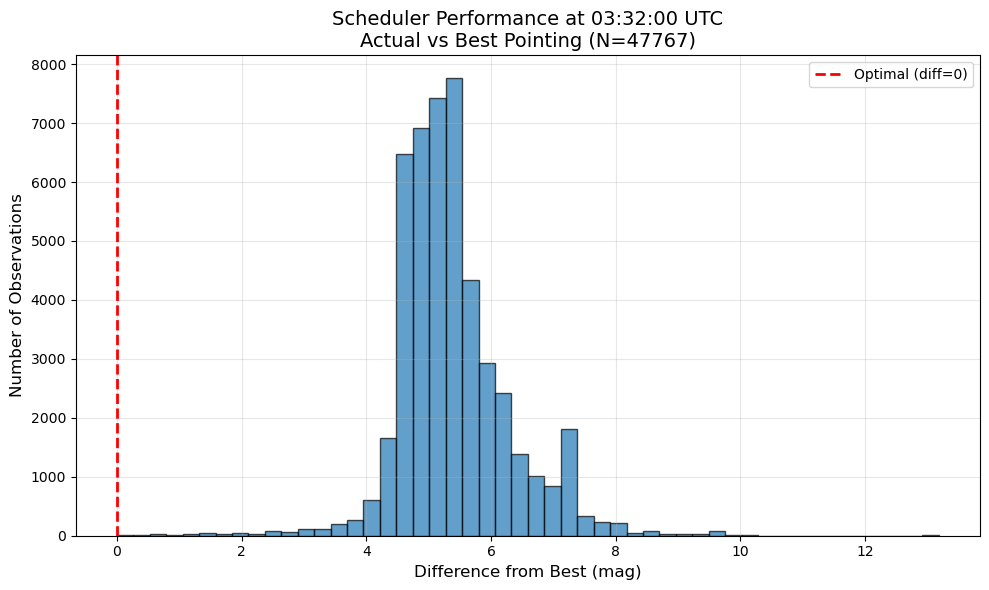

In [3]:
#!/usr/bin/env python3
"""
Analysis of all scheduler nights at a specific time of night (03:32 UTC).

1. Finds the closest chronograf map to December 6, 2025 03:32 UTC
2. For each scheduler night, finds observations near 03:32 UTC (same time of night)
3. Compares actual scheduler pointing vs best possible pointing
4. Saves results to CSV and generates histogram

Output: scheduler_at_0332utc.csv and histogram
"""

import io
import os
import sqlite3
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"
CHRONOGRAF_CSV = "all_chronograf_data.csv"
OUTPUT_CSV = "scheduler_at_0332utc.csv"
OUTPUT_HISTOGRAM = "scheduler_at_0332utc_histogram.png"

# Target time
TARGET_DATE = "2025-12-06"
TARGET_TIME_UTC = "03:32:00"  # Time of night to analyze
TIME_WINDOW_MINUTES = 15  # Match observations within ±15 minutes of 03:32

NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    """Transform https S3 paths to ResourcePath style if needed."""
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    """Fetch and read HEALPix cloud map from URL."""
    url = str(url).strip()
    if url.startswith("s3://") or url.startswith("http://") or url.startswith("https://"):
        rp = ResourcePath(url)
        with rp.open("rb") as fd:
            data = fd.read()
        bio = io.BytesIO(data)
    else:
        bio = open(url, "rb")
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None,
                     observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                     observer_height_m=RUBIN_HEIGHT_M):
    """Convert HEALPix map pixels to alt/az arrays."""
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime,
                   observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                   observer_height_m=RUBIN_HEIGHT_M):
    """Convert RA/Dec to Alt/Az at given time."""
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_best_pointing(mp, nside, obstime):
    """Find the alt/az of pixel with lowest attenuation above horizon."""
    az_deg, alt_deg, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Only consider points above horizon
    valid_mask = (alt_deg > 0) & (~np.isnan(vals))
    if not np.any(valid_mask):
        return None, None, None
    
    valid_vals = vals[valid_mask]
    valid_az = az_deg[valid_mask]
    valid_alt = alt_deg[valid_mask]
    
    min_idx = np.nanargmin(valid_vals)
    return valid_az[min_idx], valid_alt[min_idx], valid_vals[min_idx]

def get_attenuation_at_pointing(mp, nside, ra_deg, dec_deg, obstime):
    """Get cloud attenuation value at a specific RA/Dec pointing."""
    # Convert pointing to alt/az
    actual_alt, actual_az = radec_to_altaz(ra_deg, dec_deg, obstime)
    
    if actual_alt <= 0:
        return None, actual_alt, actual_az
    
    # Get all map values in alt/az
    az_arr, alt_arr, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Find nearest pixel
    d_az = np.minimum(np.abs(az_arr - actual_az), 360.0 - np.abs(az_arr - actual_az))
    distances = np.sqrt(d_az**2 + (alt_arr - actual_alt)**2)
    
    if np.all(np.isnan(vals)):
        return None, actual_alt, actual_az
    
    nearest_idx = np.nanargmin(distances)
    actual_val = vals[nearest_idx]
    
    if np.isnan(actual_val):
        return None, actual_alt, actual_az
    
    return actual_val, actual_alt, actual_az

def get_time_of_night(mjd_time):
    """Extract just the time component (HH:MM:SS) from MJD."""
    dt = Time(mjd_time, format='mjd').to_datetime()
    return dt.hour + dt.minute / 60.0 + dt.second / 3600.0  # hours as float

def time_difference_minutes(time1_hours, time2_hours):
    """Calculate time difference in minutes, handling midnight wrap."""
    diff = abs(time1_hours - time2_hours)
    # Handle wrap around midnight
    if diff > 12:
        diff = 24 - diff
    return diff * 60  # convert to minutes

# ---------------- DATA LOADING ----------------
def load_scheduler_nights(db_file):
    """Load all scheduler nights and their observations."""
    conn = sqlite3.connect(db_file)
    
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            break
    
    if table_name is None:
        table_name = tables[0][0]
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    # Find the night column
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    if night_col is None:
        raise RuntimeError(f"Could not find 'night' column.")
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    # Check for required columns
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    for req in required:
        found = False
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                found = True
                break
        if not found:
            print(f"  WARNING: Missing column: {req}")
    
    scheduler_nights = {}
    for night in obs_df['night'].unique():
        night_obs = obs_df[obs_df['night'] == night].copy()
        scheduler_nights[int(night)] = night_obs
    
    return scheduler_nights

def find_closest_map(csv_file, target_datetime):
    """Find the chronograf map closest to target datetime."""
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    # Find time and URL columns
    time_col = None
    for col in df.columns:
        if col.lower() in ['time', 'timestamp']:
            time_col = col
            break
    
    url_cols = [c for c in df.columns if c != time_col]
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    
    # Parse times with UTC=True to handle mixed timezones
    df[time_col] = df[time_col].astype(str)
    df['time'] = pd.to_datetime(df[time_col], errors='coerce', utc=True)
    df = df.dropna(subset=['time']).copy()
    
    # Already in UTC from utc=True parameter above
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    # Filter to only HDF5 files (not .gz compressed files)
    df = df[df[url_col].str.contains('.hdf5', case=False, na=False)].copy()
    
    # Also filter to cloud_sys files (not cloud_zps)
    df = df[df[url_col].str.contains('cloud_sys', case=False, na=False)].copy()
    
    if len(df) == 0:
        raise RuntimeError("No valid HDF5 cloud_sys files found in chronograf data")
    
    # Find closest time
    target = pd.to_datetime(target_datetime, utc=True)
    df['time_diff'] = abs((df['time'] - target).dt.total_seconds())
    closest_idx = df['time_diff'].idxmin()
    closest_row = df.loc[closest_idx]
    
    return closest_row[url_col], closest_row['time'].to_pydatetime(), closest_row['time_diff']

# ---------------- MAIN ANALYSIS ----------------
def analyze_time_of_night():
    """Analyze all scheduler nights at the target time of night."""
    
    print("="*80)
    print(f"ANALYZING SCHEDULER POINTINGS AT {TARGET_TIME_UTC} UTC")
    print("="*80)
    
    # Find the reference cloud map
    target_datetime = f"{TARGET_DATE}T{TARGET_TIME_UTC}"
    print(f"\nFinding closest chronograf map to {target_datetime}...")
    
    map_url, map_time, time_diff = find_closest_map(CHRONOGRAF_CSV, target_datetime)
    print(f"✓ Found map at: {map_time}")
    print(f"  Time difference: {time_diff:.1f} seconds")
    print(f"  URL: {map_url}")
    
    # Load the cloud map
    print(f"\nLoading cloud map...")
    cloud_map = fetch_map_resourcepath(map_url)
    print(f"✓ Cloud map loaded")
    
    # Find best pointing for this map
    print(f"\nFinding best possible pointing...")
    best_az, best_alt, best_atten = find_best_pointing(cloud_map, NSIDE_EXPECTED, map_time)
    print(f"✓ Best pointing: Az={best_az:.2f}°, Alt={best_alt:.2f}°, Attenuation={best_atten:.4f} mag")
    
    # Load scheduler nights
    print(f"\nLoading scheduler nights from {DB_FILE}...")
    scheduler_nights = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(scheduler_nights)} scheduler nights")
    
    # Target time of night (in hours)
    target_time_hours = 3 + 32/60.0  # 03:32 UTC
    
    print(f"\n{'='*80}")
    print(f"ANALYZING OBSERVATIONS AT ~{TARGET_TIME_UTC} UTC ACROSS ALL NIGHTS")
    print(f"Time window: ±{TIME_WINDOW_MINUTES} minutes")
    print(f"{'='*80}\n")
    
    results = []
    total_nights = len(scheduler_nights)
    
    for night_count, (sched_night, sched_obs) in enumerate(sorted(scheduler_nights.items()), 1):
        if night_count % 100 == 0:
            print(f"  Processing night {night_count}/{total_nights}...")
        
        # Find observations near target time
        for _, obs in sched_obs.iterrows():
            obs_time_hours = get_time_of_night(obs['observationStartMJD'])
            time_diff_min = time_difference_minutes(obs_time_hours, target_time_hours)
            
            if time_diff_min <= TIME_WINDOW_MINUTES:
                # Get attenuation at actual pointing
                actual_atten, actual_alt, actual_az = get_attenuation_at_pointing(
                    cloud_map, NSIDE_EXPECTED,
                    obs['fieldRA'], obs['fieldDec'], map_time)
                
                if actual_atten is not None:
                    difference = actual_atten - best_atten
                    obs_datetime = Time(obs['observationStartMJD'], format='mjd').to_datetime()
                    
                    results.append({
                        'scheduler_night': sched_night,
                        'obs_mjd': obs['observationStartMJD'],
                        'obs_datetime_utc': obs_datetime.isoformat(),
                        'obs_time_utc': obs_datetime.strftime('%H:%M:%S'),
                        'time_diff_minutes': time_diff_min,
                        'best_attenuation': best_atten,
                        'best_az': best_az,
                        'best_alt': best_alt,
                        'actual_attenuation': actual_atten,
                        'actual_az': actual_az,
                        'actual_alt': actual_alt,
                        'difference': difference,
                        'obs_ra': obs['fieldRA'],
                        'obs_dec': obs['fieldDec'],
                        'obs_band': obs.get('band', 'unknown'),
                        'obs_filter': obs.get('filter', 'unknown'),
                        'reference_map_time': map_time.isoformat()
                    })
    
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*80}")
    
    if len(results) == 0:
        print("\n✗ No observations found at target time")
        return
    
    # Save results
    results_df = pd.DataFrame(results)
    results_df.to_csv(OUTPUT_CSV, index=False)
    
    print(f"\n✓ Results saved to {OUTPUT_CSV}")
    print(f"✓ Total observations analyzed: {len(results)}")
    print(f"✓ Nights with observations at this time: {results_df['scheduler_night'].nunique()}")
    
    # Statistics
    print(f"\nSummary Statistics:")
    print(f"  Mean difference: {results_df['difference'].mean():.4f} mag")
    print(f"  Median difference: {results_df['difference'].median():.4f} mag")
    print(f"  Std difference: {results_df['difference'].std():.4f} mag")
    print(f"  Min difference: {results_df['difference'].min():.4f} mag")
    print(f"  Max difference: {results_df['difference'].max():.4f} mag")
    print(f"  % worse than best (diff > 0.05): {(results_df['difference'] > 0.05).sum() / len(results_df) * 100:.1f}%")
    
    # Create histogram
    print(f"\nGenerating histogram...")
    plt.figure(figsize=(10, 6))
    plt.hist(results_df['difference'], bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Optimal (diff=0)')
    plt.xlabel('Difference from Best (mag)', fontsize=12)
    plt.ylabel('Number of Observations', fontsize=12)
    plt.title(f'Scheduler Performance at {TARGET_TIME_UTC} UTC\nActual vs Best Pointing (N={len(results)})', fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_HISTOGRAM, dpi=150)
    print(f"✓ Histogram saved to {OUTPUT_HISTOGRAM}")
    
    # Show distribution percentiles
    print(f"\nPercentiles of difference:")
    for p in [10, 25, 50, 75, 90, 95, 99]:
        val = np.percentile(results_df['difference'], p)
        print(f"  {p:2d}th percentile: {val:.4f} mag")

if __name__ == "__main__":
    analyze_time_of_night()

ANALYZING SCHEDULER POINTINGS AT 06:24:00 UTC

Finding closest chronograf map to 2025-12-14T06:24:00...
✓ Found map at: 2025-12-14 03:29:22.048000+00:00
  Time difference: 10478.0 seconds
  URL: s3://lfa@rubinobs-lfa-cp/DREAM/dream/2025/12/13/DREAM_dream_2025-12-14T03:29:12.503_B_cloud_sys_64034900_64034903_r0.hdf5

Loading cloud map...
✓ Cloud map loaded

Finding best possible pointing...
✓ Best pointing: Az=183.74°, Alt=65.90°, Attenuation=-0.4825 mag

Loading scheduler nights from baseline_v5.1.0_10yrs.db...
✓ Loaded 2771 scheduler nights

ANALYZING OBSERVATIONS AT ~06:24:00 UTC ACROSS ALL NIGHTS
Time window: ±15 minutes

  Processing night 100/2771...
  Processing night 200/2771...
  Processing night 300/2771...
  Processing night 400/2771...
  Processing night 500/2771...
  Processing night 600/2771...
  Processing night 700/2771...
  Processing night 800/2771...


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  Processing night 900/2771...
  Processing night 1000/2771...
  Processing night 1100/2771...
  Processing night 1200/2771...
  Processing night 1300/2771...
  Processing night 1400/2771...
  Processing night 1500/2771...
  Processing night 1600/2771...
  Processing night 1700/2771...
  Processing night 1800/2771...
  Processing night 1900/2771...
  Processing night 2000/2771...
  Processing night 2100/2771...
  Processing night 2200/2771...
  Processing night 2300/2771...
  Processing night 2400/2771...
  Processing night 2500/2771...
  Processing night 2600/2771...
  Processing night 2700/2771...

ANALYSIS COMPLETE

✓ Results saved to scheduler_at_0332utc.csv
✓ Total observations analyzed: 48470
✓ Nights with observations at this time: 1546

Summary Statistics:
  Mean difference: 0.5816 mag
  Median difference: 0.5828 mag
  Std difference: 0.0651 mag
  Min difference: 0.0000 mag
  Max difference: 1.8079 mag
  % worse than best (diff > 0.05): 100.0%

Generating histogram...
✓ Histogr

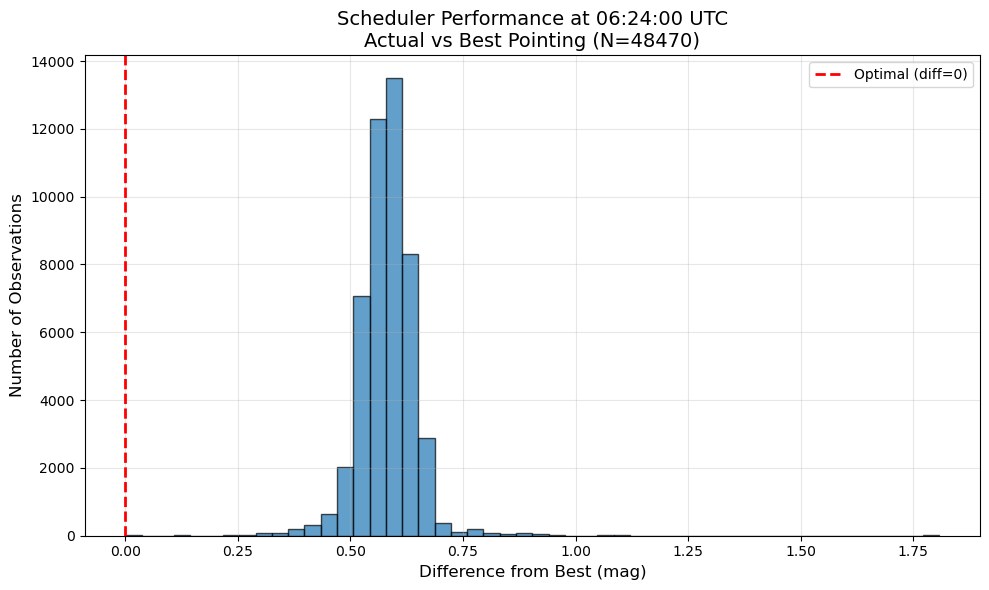

In [4]:
#!/usr/bin/env python3
"""
Analysis of all scheduler nights at a specific time of night (03:32 UTC).

1. Finds the closest chronograf map to December 6, 2025 03:32 UTC
2. For each scheduler night, finds observations near 03:32 UTC (same time of night)
3. Compares actual scheduler pointing vs best possible pointing
4. Saves results to CSV and generates histogram

Output: scheduler_at_0332utc.csv and histogram
"""

import io
import os
import sqlite3
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"
CHRONOGRAF_CSV = "all_chronograf_data.csv"
OUTPUT_CSV = "scheduler_at_0332utc.csv"
OUTPUT_HISTOGRAM = "scheduler_at_0332utc_histogram.png"

# Target time
TARGET_DATE = "2025-12-14"
TARGET_TIME_UTC = "06:24:00"  # Time of night to analyze
TIME_WINDOW_MINUTES = 15  # Match observations within ±15 minutes of 03:32

NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    """Transform https S3 paths to ResourcePath style if needed."""
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    """Fetch and read HEALPix cloud map from URL."""
    url = str(url).strip()
    if url.startswith("s3://") or url.startswith("http://") or url.startswith("https://"):
        rp = ResourcePath(url)
        with rp.open("rb") as fd:
            data = fd.read()
        bio = io.BytesIO(data)
    else:
        bio = open(url, "rb")
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None,
                     observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                     observer_height_m=RUBIN_HEIGHT_M):
    """Convert HEALPix map pixels to alt/az arrays."""
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime,
                   observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                   observer_height_m=RUBIN_HEIGHT_M):
    """Convert RA/Dec to Alt/Az at given time."""
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_best_pointing(mp, nside, obstime):
    """Find the alt/az of pixel with lowest attenuation above horizon."""
    az_deg, alt_deg, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Only consider points above horizon
    valid_mask = (alt_deg > 0) & (~np.isnan(vals))
    if not np.any(valid_mask):
        return None, None, None
    
    valid_vals = vals[valid_mask]
    valid_az = az_deg[valid_mask]
    valid_alt = alt_deg[valid_mask]
    
    min_idx = np.nanargmin(valid_vals)
    return valid_az[min_idx], valid_alt[min_idx], valid_vals[min_idx]

def get_attenuation_at_pointing(mp, nside, ra_deg, dec_deg, obstime):
    """Get cloud attenuation value at a specific RA/Dec pointing."""
    # Convert pointing to alt/az
    actual_alt, actual_az = radec_to_altaz(ra_deg, dec_deg, obstime)
    
    if actual_alt <= 0:
        return None, actual_alt, actual_az
    
    # Get all map values in alt/az
    az_arr, alt_arr, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Find nearest pixel
    d_az = np.minimum(np.abs(az_arr - actual_az), 360.0 - np.abs(az_arr - actual_az))
    distances = np.sqrt(d_az**2 + (alt_arr - actual_alt)**2)
    
    if np.all(np.isnan(vals)):
        return None, actual_alt, actual_az
    
    nearest_idx = np.nanargmin(distances)
    actual_val = vals[nearest_idx]
    
    if np.isnan(actual_val):
        return None, actual_alt, actual_az
    
    return actual_val, actual_alt, actual_az

def get_time_of_night(mjd_time):
    """Extract just the time component (HH:MM:SS) from MJD."""
    dt = Time(mjd_time, format='mjd').to_datetime()
    return dt.hour + dt.minute / 60.0 + dt.second / 3600.0  # hours as float

def time_difference_minutes(time1_hours, time2_hours):
    """Calculate time difference in minutes, handling midnight wrap."""
    diff = abs(time1_hours - time2_hours)
    # Handle wrap around midnight
    if diff > 12:
        diff = 24 - diff
    return diff * 60  # convert to minutes

# ---------------- DATA LOADING ----------------
def load_scheduler_nights(db_file):
    """Load all scheduler nights and their observations."""
    conn = sqlite3.connect(db_file)
    
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            break
    
    if table_name is None:
        table_name = tables[0][0]
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    # Find the night column
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    if night_col is None:
        raise RuntimeError(f"Could not find 'night' column.")
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    # Check for required columns
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    for req in required:
        found = False
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                found = True
                break
        if not found:
            print(f"  WARNING: Missing column: {req}")
    
    scheduler_nights = {}
    for night in obs_df['night'].unique():
        night_obs = obs_df[obs_df['night'] == night].copy()
        scheduler_nights[int(night)] = night_obs
    
    return scheduler_nights

def find_closest_map(csv_file, target_datetime):
    """Find the chronograf map closest to target datetime."""
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    # Find time and URL columns
    time_col = None
    for col in df.columns:
        if col.lower() in ['time', 'timestamp']:
            time_col = col
            break
    
    url_cols = [c for c in df.columns if c != time_col]
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    
    # Parse times with UTC=True to handle mixed timezones
    df[time_col] = df[time_col].astype(str)
    df['time'] = pd.to_datetime(df[time_col], errors='coerce', utc=True)
    df = df.dropna(subset=['time']).copy()
    
    # Already in UTC from utc=True parameter above
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    # Filter to only HDF5 files (not .gz compressed files)
    df = df[df[url_col].str.contains('.hdf5', case=False, na=False)].copy()
    
    # Also filter to cloud_sys files (not cloud_zps)
    df = df[df[url_col].str.contains('cloud_sys', case=False, na=False)].copy()
    
    if len(df) == 0:
        raise RuntimeError("No valid HDF5 cloud_sys files found in chronograf data")
    
    # Find closest time
    target = pd.to_datetime(target_datetime, utc=True)
    df['time_diff'] = abs((df['time'] - target).dt.total_seconds())
    closest_idx = df['time_diff'].idxmin()
    closest_row = df.loc[closest_idx]
    
    return closest_row[url_col], closest_row['time'].to_pydatetime(), closest_row['time_diff']

# ---------------- MAIN ANALYSIS ----------------
def analyze_time_of_night():
    """Analyze all scheduler nights at the target time of night."""
    
    print("="*80)
    print(f"ANALYZING SCHEDULER POINTINGS AT {TARGET_TIME_UTC} UTC")
    print("="*80)
    
    # Find the reference cloud map
    target_datetime = f"{TARGET_DATE}T{TARGET_TIME_UTC}"
    print(f"\nFinding closest chronograf map to {target_datetime}...")
    
    map_url, map_time, time_diff = find_closest_map(CHRONOGRAF_CSV, target_datetime)
    print(f"✓ Found map at: {map_time}")
    print(f"  Time difference: {time_diff:.1f} seconds")
    print(f"  URL: {map_url}")
    
    # Load the cloud map
    print(f"\nLoading cloud map...")
    cloud_map = fetch_map_resourcepath(map_url)
    print(f"✓ Cloud map loaded")
    
    # Find best pointing for this map
    print(f"\nFinding best possible pointing...")
    best_az, best_alt, best_atten = find_best_pointing(cloud_map, NSIDE_EXPECTED, map_time)
    print(f"✓ Best pointing: Az={best_az:.2f}°, Alt={best_alt:.2f}°, Attenuation={best_atten:.4f} mag")
    
    # Load scheduler nights
    print(f"\nLoading scheduler nights from {DB_FILE}...")
    scheduler_nights = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(scheduler_nights)} scheduler nights")
    
    # Target time of night (in hours)
    target_time_hours = 3 + 32/60.0  # 03:32 UTC
    
    print(f"\n{'='*80}")
    print(f"ANALYZING OBSERVATIONS AT ~{TARGET_TIME_UTC} UTC ACROSS ALL NIGHTS")
    print(f"Time window: ±{TIME_WINDOW_MINUTES} minutes")
    print(f"{'='*80}\n")
    
    results = []
    total_nights = len(scheduler_nights)
    
    for night_count, (sched_night, sched_obs) in enumerate(sorted(scheduler_nights.items()), 1):
        if night_count % 100 == 0:
            print(f"  Processing night {night_count}/{total_nights}...")
        
        # Find observations near target time
        for _, obs in sched_obs.iterrows():
            obs_time_hours = get_time_of_night(obs['observationStartMJD'])
            time_diff_min = time_difference_minutes(obs_time_hours, target_time_hours)
            
            if time_diff_min <= TIME_WINDOW_MINUTES:
                # Get attenuation at actual pointing
                actual_atten, actual_alt, actual_az = get_attenuation_at_pointing(
                    cloud_map, NSIDE_EXPECTED,
                    obs['fieldRA'], obs['fieldDec'], map_time)
                
                if actual_atten is not None:
                    difference = actual_atten - best_atten
                    obs_datetime = Time(obs['observationStartMJD'], format='mjd').to_datetime()
                    
                    results.append({
                        'scheduler_night': sched_night,
                        'obs_mjd': obs['observationStartMJD'],
                        'obs_datetime_utc': obs_datetime.isoformat(),
                        'obs_time_utc': obs_datetime.strftime('%H:%M:%S'),
                        'time_diff_minutes': time_diff_min,
                        'best_attenuation': best_atten,
                        'best_az': best_az,
                        'best_alt': best_alt,
                        'actual_attenuation': actual_atten,
                        'actual_az': actual_az,
                        'actual_alt': actual_alt,
                        'difference': difference,
                        'obs_ra': obs['fieldRA'],
                        'obs_dec': obs['fieldDec'],
                        'obs_band': obs.get('band', 'unknown'),
                        'obs_filter': obs.get('filter', 'unknown'),
                        'reference_map_time': map_time.isoformat()
                    })
    
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*80}")
    
    if len(results) == 0:
        print("\n✗ No observations found at target time")
        return
    
    # Save results
    results_df = pd.DataFrame(results)
    results_df.to_csv(OUTPUT_CSV, index=False)
    
    print(f"\n✓ Results saved to {OUTPUT_CSV}")
    print(f"✓ Total observations analyzed: {len(results)}")
    print(f"✓ Nights with observations at this time: {results_df['scheduler_night'].nunique()}")
    
    # Statistics
    print(f"\nSummary Statistics:")
    print(f"  Mean difference: {results_df['difference'].mean():.4f} mag")
    print(f"  Median difference: {results_df['difference'].median():.4f} mag")
    print(f"  Std difference: {results_df['difference'].std():.4f} mag")
    print(f"  Min difference: {results_df['difference'].min():.4f} mag")
    print(f"  Max difference: {results_df['difference'].max():.4f} mag")
    print(f"  % worse than best (diff > 0.05): {(results_df['difference'] > 0.05).sum() / len(results_df) * 100:.1f}%")
    
    # Create histogram
    print(f"\nGenerating histogram...")
    plt.figure(figsize=(10, 6))
    plt.hist(results_df['difference'], bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Optimal (diff=0)')
    plt.xlabel('Difference from Best (mag)', fontsize=12)
    plt.ylabel('Number of Observations', fontsize=12)
    plt.title(f'Scheduler Performance at {TARGET_TIME_UTC} UTC\nActual vs Best Pointing (N={len(results)})', fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_HISTOGRAM, dpi=150)
    print(f"✓ Histogram saved to {OUTPUT_HISTOGRAM}")
    
    # Show distribution percentiles
    print(f"\nPercentiles of difference:")
    for p in [10, 25, 50, 75, 90, 95, 99]:
        val = np.percentile(results_df['difference'], p)
        print(f"  {p:2d}th percentile: {val:.4f} mag")

if __name__ == "__main__":
    analyze_time_of_night()

ANALYZING SCHEDULER POINTINGS AT 05:44:00 UTC

Finding closest chronograf map to 2025-10-15T05:44:00...
✓ Found map at: 2025-10-15 05:44:14.105000+00:00
  Time difference: 14.1 seconds
  URL: s3://lfa@rubinobs-lfa-cp/DREAM/dream/2025/10/14/DREAM_dream_2025-10-15T05:44:03.726_B_cloud_sys_63223950_63223953_r0.hdf5

Loading cloud map...
✓ Cloud map loaded

Finding best possible pointing...
✓ Best pointing: Az=304.46°, Alt=19.37°, Attenuation=1.3080 mag

Loading scheduler nights from baseline_v5.1.0_10yrs.db...
✓ Loaded 2771 scheduler nights

ANALYZING OBSERVATIONS AT ~05:44:00 UTC ACROSS ALL NIGHTS
Time window: ±15 minutes

  Processing night 100/2771...
  Processing night 200/2771...
  Processing night 300/2771...
  Processing night 400/2771...
  Processing night 500/2771...
  Processing night 600/2771...
  Processing night 700/2771...
  Processing night 800/2771...


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  Processing night 900/2771...
  Processing night 1000/2771...
  Processing night 1100/2771...
  Processing night 1200/2771...
  Processing night 1300/2771...
  Processing night 1400/2771...
  Processing night 1500/2771...
  Processing night 1600/2771...
  Processing night 1700/2771...
  Processing night 1800/2771...
  Processing night 1900/2771...
  Processing night 2000/2771...
  Processing night 2100/2771...
  Processing night 2200/2771...
  Processing night 2300/2771...
  Processing night 2400/2771...
  Processing night 2500/2771...
  Processing night 2600/2771...
  Processing night 2700/2771...

ANALYSIS COMPLETE

✓ Results saved to scheduler_at_0332utc.csv
✓ Total observations analyzed: 47603
✓ Nights with observations at this time: 1418

Summary Statistics:
  Mean difference: 1.4261 mag
  Median difference: 1.3183 mag
  Std difference: 0.4387 mag
  Min difference: 0.2081 mag
  Max difference: 4.2728 mag
  % worse than best (diff > 0.05): 100.0%

Generating histogram...
✓ Histogr

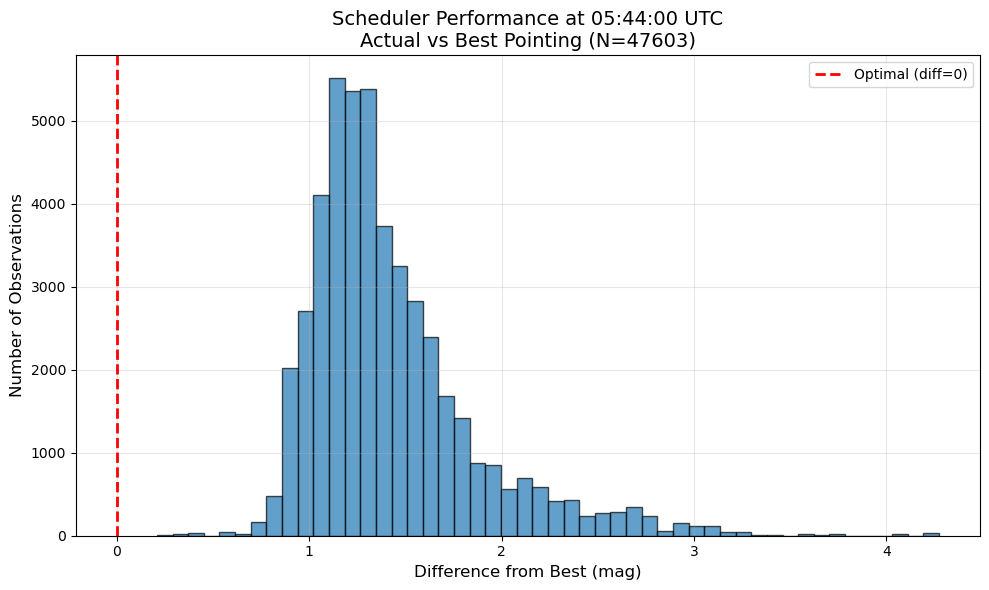

In [5]:
#!/usr/bin/env python3
"""
Analysis of all scheduler nights at a specific time of night (03:32 UTC).

1. Finds the closest chronograf map to December 6, 2025 03:32 UTC
2. For each scheduler night, finds observations near 03:32 UTC (same time of night)
3. Compares actual scheduler pointing vs best possible pointing
4. Saves results to CSV and generates histogram

Output: scheduler_at_0332utc.csv and histogram
"""

import io
import os
import sqlite3
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"
CHRONOGRAF_CSV = "all_chronograf_data.csv"
OUTPUT_CSV = "scheduler_at_0332utc.csv"
OUTPUT_HISTOGRAM = "scheduler_at_0332utc_histogram.png"

# Target time
TARGET_DATE = "2025-10-15"
TARGET_TIME_UTC = "05:44:00"  # Time of night to analyze
TIME_WINDOW_MINUTES = 15  # Match observations within ±15 minutes of 03:32

NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    """Transform https S3 paths to ResourcePath style if needed."""
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    """Fetch and read HEALPix cloud map from URL."""
    url = str(url).strip()
    if url.startswith("s3://") or url.startswith("http://") or url.startswith("https://"):
        rp = ResourcePath(url)
        with rp.open("rb") as fd:
            data = fd.read()
        bio = io.BytesIO(data)
    else:
        bio = open(url, "rb")
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None,
                     observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                     observer_height_m=RUBIN_HEIGHT_M):
    """Convert HEALPix map pixels to alt/az arrays."""
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime,
                   observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                   observer_height_m=RUBIN_HEIGHT_M):
    """Convert RA/Dec to Alt/Az at given time."""
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_best_pointing(mp, nside, obstime):
    """Find the alt/az of pixel with lowest attenuation above horizon."""
    az_deg, alt_deg, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Only consider points above horizon
    valid_mask = (alt_deg > 0) & (~np.isnan(vals))
    if not np.any(valid_mask):
        return None, None, None
    
    valid_vals = vals[valid_mask]
    valid_az = az_deg[valid_mask]
    valid_alt = alt_deg[valid_mask]
    
    min_idx = np.nanargmin(valid_vals)
    return valid_az[min_idx], valid_alt[min_idx], valid_vals[min_idx]

def get_attenuation_at_pointing(mp, nside, ra_deg, dec_deg, obstime):
    """Get cloud attenuation value at a specific RA/Dec pointing."""
    # Convert pointing to alt/az
    actual_alt, actual_az = radec_to_altaz(ra_deg, dec_deg, obstime)
    
    if actual_alt <= 0:
        return None, actual_alt, actual_az
    
    # Get all map values in alt/az
    az_arr, alt_arr, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    # Find nearest pixel
    d_az = np.minimum(np.abs(az_arr - actual_az), 360.0 - np.abs(az_arr - actual_az))
    distances = np.sqrt(d_az**2 + (alt_arr - actual_alt)**2)
    
    if np.all(np.isnan(vals)):
        return None, actual_alt, actual_az
    
    nearest_idx = np.nanargmin(distances)
    actual_val = vals[nearest_idx]
    
    if np.isnan(actual_val):
        return None, actual_alt, actual_az
    
    return actual_val, actual_alt, actual_az

def get_time_of_night(mjd_time):
    """Extract just the time component (HH:MM:SS) from MJD."""
    dt = Time(mjd_time, format='mjd').to_datetime()
    return dt.hour + dt.minute / 60.0 + dt.second / 3600.0  # hours as float

def time_difference_minutes(time1_hours, time2_hours):
    """Calculate time difference in minutes, handling midnight wrap."""
    diff = abs(time1_hours - time2_hours)
    # Handle wrap around midnight
    if diff > 12:
        diff = 24 - diff
    return diff * 60  # convert to minutes

# ---------------- DATA LOADING ----------------
def load_scheduler_nights(db_file):
    """Load all scheduler nights and their observations."""
    conn = sqlite3.connect(db_file)
    
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            break
    
    if table_name is None:
        table_name = tables[0][0]
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    # Find the night column
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    if night_col is None:
        raise RuntimeError(f"Could not find 'night' column.")
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    # Check for required columns
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    for req in required:
        found = False
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                found = True
                break
        if not found:
            print(f"  WARNING: Missing column: {req}")
    
    scheduler_nights = {}
    for night in obs_df['night'].unique():
        night_obs = obs_df[obs_df['night'] == night].copy()
        scheduler_nights[int(night)] = night_obs
    
    return scheduler_nights

def find_closest_map(csv_file, target_datetime):
    """Find the chronograf map closest to target datetime."""
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    # Find time and URL columns
    time_col = None
    for col in df.columns:
        if col.lower() in ['time', 'timestamp']:
            time_col = col
            break
    
    url_cols = [c for c in df.columns if c != time_col]
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    
    # Parse times with UTC=True to handle mixed timezones
    df[time_col] = df[time_col].astype(str)
    df['time'] = pd.to_datetime(df[time_col], errors='coerce', utc=True)
    df = df.dropna(subset=['time']).copy()
    
    # Already in UTC from utc=True parameter above
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    # Filter to only HDF5 files (not .gz compressed files)
    df = df[df[url_col].str.contains('.hdf5', case=False, na=False)].copy()
    
    # Also filter to cloud_sys files (not cloud_zps)
    df = df[df[url_col].str.contains('cloud_sys', case=False, na=False)].copy()
    
    if len(df) == 0:
        raise RuntimeError("No valid HDF5 cloud_sys files found in chronograf data")
    
    # Find closest time
    target = pd.to_datetime(target_datetime, utc=True)
    df['time_diff'] = abs((df['time'] - target).dt.total_seconds())
    closest_idx = df['time_diff'].idxmin()
    closest_row = df.loc[closest_idx]
    
    return closest_row[url_col], closest_row['time'].to_pydatetime(), closest_row['time_diff']

# ---------------- MAIN ANALYSIS ----------------
def analyze_time_of_night():
    """Analyze all scheduler nights at the target time of night."""
    
    print("="*80)
    print(f"ANALYZING SCHEDULER POINTINGS AT {TARGET_TIME_UTC} UTC")
    print("="*80)
    
    # Find the reference cloud map
    target_datetime = f"{TARGET_DATE}T{TARGET_TIME_UTC}"
    print(f"\nFinding closest chronograf map to {target_datetime}...")
    
    map_url, map_time, time_diff = find_closest_map(CHRONOGRAF_CSV, target_datetime)
    print(f"✓ Found map at: {map_time}")
    print(f"  Time difference: {time_diff:.1f} seconds")
    print(f"  URL: {map_url}")
    
    # Load the cloud map
    print(f"\nLoading cloud map...")
    cloud_map = fetch_map_resourcepath(map_url)
    print(f"✓ Cloud map loaded")
    
    # Find best pointing for this map
    print(f"\nFinding best possible pointing...")
    best_az, best_alt, best_atten = find_best_pointing(cloud_map, NSIDE_EXPECTED, map_time)
    print(f"✓ Best pointing: Az={best_az:.2f}°, Alt={best_alt:.2f}°, Attenuation={best_atten:.4f} mag")
    
    # Load scheduler nights
    print(f"\nLoading scheduler nights from {DB_FILE}...")
    scheduler_nights = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(scheduler_nights)} scheduler nights")
    
    # Target time of night (in hours)
    target_time_hours = 3 + 32/60.0  # 03:32 UTC
    
    print(f"\n{'='*80}")
    print(f"ANALYZING OBSERVATIONS AT ~{TARGET_TIME_UTC} UTC ACROSS ALL NIGHTS")
    print(f"Time window: ±{TIME_WINDOW_MINUTES} minutes")
    print(f"{'='*80}\n")
    
    results = []
    total_nights = len(scheduler_nights)
    
    for night_count, (sched_night, sched_obs) in enumerate(sorted(scheduler_nights.items()), 1):
        if night_count % 100 == 0:
            print(f"  Processing night {night_count}/{total_nights}...")
        
        # Find observations near target time
        for _, obs in sched_obs.iterrows():
            obs_time_hours = get_time_of_night(obs['observationStartMJD'])
            time_diff_min = time_difference_minutes(obs_time_hours, target_time_hours)
            
            if time_diff_min <= TIME_WINDOW_MINUTES:
                # Get attenuation at actual pointing
                actual_atten, actual_alt, actual_az = get_attenuation_at_pointing(
                    cloud_map, NSIDE_EXPECTED,
                    obs['fieldRA'], obs['fieldDec'], map_time)
                
                if actual_atten is not None:
                    difference = actual_atten - best_atten
                    obs_datetime = Time(obs['observationStartMJD'], format='mjd').to_datetime()
                    
                    results.append({
                        'scheduler_night': sched_night,
                        'obs_mjd': obs['observationStartMJD'],
                        'obs_datetime_utc': obs_datetime.isoformat(),
                        'obs_time_utc': obs_datetime.strftime('%H:%M:%S'),
                        'time_diff_minutes': time_diff_min,
                        'best_attenuation': best_atten,
                        'best_az': best_az,
                        'best_alt': best_alt,
                        'actual_attenuation': actual_atten,
                        'actual_az': actual_az,
                        'actual_alt': actual_alt,
                        'difference': difference,
                        'obs_ra': obs['fieldRA'],
                        'obs_dec': obs['fieldDec'],
                        'obs_band': obs.get('band', 'unknown'),
                        'obs_filter': obs.get('filter', 'unknown'),
                        'reference_map_time': map_time.isoformat()
                    })
    
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*80}")
    
    if len(results) == 0:
        print("\n✗ No observations found at target time")
        return
    
    # Save results
    results_df = pd.DataFrame(results)
    results_df.to_csv(OUTPUT_CSV, index=False)
    
    print(f"\n✓ Results saved to {OUTPUT_CSV}")
    print(f"✓ Total observations analyzed: {len(results)}")
    print(f"✓ Nights with observations at this time: {results_df['scheduler_night'].nunique()}")
    
    # Statistics
    print(f"\nSummary Statistics:")
    print(f"  Mean difference: {results_df['difference'].mean():.4f} mag")
    print(f"  Median difference: {results_df['difference'].median():.4f} mag")
    print(f"  Std difference: {results_df['difference'].std():.4f} mag")
    print(f"  Min difference: {results_df['difference'].min():.4f} mag")
    print(f"  Max difference: {results_df['difference'].max():.4f} mag")
    print(f"  % worse than best (diff > 0.05): {(results_df['difference'] > 0.05).sum() / len(results_df) * 100:.1f}%")
    
    # Create histogram
    print(f"\nGenerating histogram...")
    plt.figure(figsize=(10, 6))
    plt.hist(results_df['difference'], bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Optimal (diff=0)')
    plt.xlabel('Difference from Best (mag)', fontsize=12)
    plt.ylabel('Number of Observations', fontsize=12)
    plt.title(f'Scheduler Performance at {TARGET_TIME_UTC} UTC\nActual vs Best Pointing (N={len(results)})', fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_HISTOGRAM, dpi=150)
    print(f"✓ Histogram saved to {OUTPUT_HISTOGRAM}")
    
    # Show distribution percentiles
    print(f"\nPercentiles of difference:")
    for p in [10, 25, 50, 75, 90, 95, 99]:
        val = np.percentile(results_df['difference'], p)
        print(f"  {p:2d}th percentile: {val:.4f} mag")

if __name__ == "__main__":
    analyze_time_of_night()

In [6]:
#!/usr/bin/env python3
"""
Orthographic sky plots matching fixed DREAM plotting style
"""

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.time import Time

# ---------------- PARAMETERS ----------------
NSIDE_EXPECTED = 32
NEST = True
CBAR_VMIN = -0.2
CBAR_VMAX = 2.0

# ---------------- PROJECTION ----------------
def ortho_projection(az, alt):
    x = np.cos(np.radians(alt)) * np.sin(np.radians(az))
    y = np.sin(np.radians(alt))
    visible = alt > 0
    return x[visible], y[visible], visible

# ---------------- MAIN PLOT ----------------
def plot_analysis(npz_file, title):
    data = np.load(npz_file, allow_pickle=True)

    cloud_map = data["cloud_map"]
    best_az = float(data["best_az"])
    best_alt = float(data["best_alt"])
    map_time = Time(str(data["map_time"]))

    # Convert map to alt/az
    pix = np.arange(hp.nside2npix(NSIDE_EXPECTED))
    theta, phi = hp.pix2ang(NSIDE_EXPECTED, pix, nest=NEST)
    ra = np.degrees(phi)
    dec = 90.0 - np.degrees(theta)

    from astropy.coordinates import SkyCoord, EarthLocation, AltAz
    import astropy.units as u

    loc = EarthLocation(lat=-30.244639*u.deg,
                        lon=-70.749417*u.deg,
                        height=2663*u.m)

    sky = SkyCoord(ra*u.deg, dec*u.deg)
    altaz = sky.transform_to(AltAz(obstime=map_time, location=loc))

    az = altaz.az.deg
    alt = altaz.alt.deg
    vals = np.where(cloud_map == hp.UNSEEN, np.nan, cloud_map)

    x, y, vis = ortho_projection(az, alt)

    fig, ax = plt.subplots(figsize=(7, 7))
    sc = ax.scatter(
        x, y,
        c=vals[vis],
        s=6,
        cmap="viridis",
        vmin=CBAR_VMIN,
        vmax=CBAR_VMAX
    )

    # Best pointing
    bx, by, _ = ortho_projection(
        np.array([best_az]),
        np.array([best_alt])
    )
    ax.scatter(bx, by, s=120, c="red", marker="*", label="Best pointing")

    ax.set_aspect("equal")
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=14)

    cbar = plt.colorbar(sc, ax=ax, fraction=0.046)
    cbar.set_label("Cloud attenuation (mag)")

    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()


In [ ]:
#!/usr/bin/env python3
"""
Multi-time point analysis with polar projections, histograms, and fake scenarios.

Analyzes three specific time points:
1. 2025-12-06 03:32 UTC
2. 2025-12-14 06:24 UTC  
3. 2025-10-15 05:44 UTC

For each: polar map, histogram of attenuations, scheduler pointing analysis
Plus: fake scenarios (zero, uniform 10, half-and-half)
"""

import io
import os
import sqlite3
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"
CHRONOGRAF_CSV = "all_chronograf_data.csv"

# Three target times
TARGETS = [
    {"date": "2025-12-06", "time": "03:32:00", "name": "Dec06_0332"},
    {"date": "2025-12-14", "time": "06:24:00", "name": "Dec14_0624"},
    {"date": "2025-10-15", "time": "05:44:00", "name": "Oct15_0544"},
]

TIME_WINDOW_MINUTES = 15
NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0
CBAR_VMIN = -0.2
CBAR_VMAX = 2.0

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    url = str(url).strip()
    if url.startswith("s3://") or url.startswith("http://") or url.startswith("https://"):
        rp = ResourcePath(url)
        with rp.open("rb") as fd:
            data = fd.read()
        bio = io.BytesIO(data)
    else:
        bio = open(url, "rb")
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None,
                     observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                     observer_height_m=RUBIN_HEIGHT_M):
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime,
                   observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                   observer_height_m=RUBIN_HEIGHT_M):
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_best_pointing(mp, nside, obstime):
    az_deg, alt_deg, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    valid_mask = (alt_deg > 0) & (~np.isnan(vals))
    if not np.any(valid_mask):
        return None, None, None
    
    valid_vals = vals[valid_mask]
    valid_az = az_deg[valid_mask]
    valid_alt = alt_deg[valid_mask]
    
    min_idx = np.nanargmin(valid_vals)
    return valid_az[min_idx], valid_alt[min_idx], valid_vals[min_idx]

def get_attenuation_at_pointing(mp, nside, ra_deg, dec_deg, obstime):
    actual_alt, actual_az = radec_to_altaz(ra_deg, dec_deg, obstime)
    
    if actual_alt <= 0:
        return None, actual_alt, actual_az
    
    az_arr, alt_arr, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    d_az = np.minimum(np.abs(az_arr - actual_az), 360.0 - np.abs(az_arr - actual_az))
    distances = np.sqrt(d_az**2 + (alt_arr - actual_alt)**2)
    
    if np.all(np.isnan(vals)):
        return None, actual_alt, actual_az
    
    nearest_idx = np.nanargmin(distances)
    actual_val = vals[nearest_idx]
    
    if np.isnan(actual_val):
        return None, actual_alt, actual_az
    
    return actual_val, actual_alt, actual_az

def get_time_of_night(mjd_time):
    dt = Time(mjd_time, format='mjd').to_datetime()
    return dt.hour + dt.minute / 60.0 + dt.second / 3600.0

def time_difference_minutes(time1_hours, time2_hours):
    diff = abs(time1_hours - time2_hours)
    if diff > 12:
        diff = 24 - diff
    return diff * 60

def load_scheduler_nights(db_file):
    conn = sqlite3.connect(db_file)
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            break
    
    if table_name is None:
        table_name = tables[0][0]
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    for req in required:
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                break
    
    scheduler_nights = {}
    for night in obs_df['night'].unique():
        night_obs = obs_df[obs_df['night'] == night].copy()
        scheduler_nights[int(night)] = night_obs
    
    return scheduler_nights

def find_closest_map(csv_file, target_datetime):
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    time_col = None
    for col in df.columns:
        if col.lower() in ['time', 'timestamp']:
            time_col = col
            break
    
    url_cols = [c for c in df.columns if c != time_col]
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    df[time_col] = df[time_col].astype(str)
    df['time'] = pd.to_datetime(df[time_col], errors='coerce', utc=True)
    df = df.dropna(subset=['time']).copy()
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    df = df[df[url_col].str.contains('.hdf5', case=False, na=False)].copy()
    df = df[df[url_col].str.contains('cloud_sys', case=False, na=False)].copy()
    
    if len(df) == 0:
        raise RuntimeError("No valid HDF5 cloud_sys files found")
    
    target = pd.to_datetime(target_datetime, utc=True)
    df['time_diff'] = abs((df['time'] - target).dt.total_seconds())
    closest_idx = df['time_diff'].idxmin()
    closest_row = df.loc[closest_idx]
    
    return closest_row[url_col], closest_row['time'].to_pydatetime(), closest_row['time_diff']

def plot_polar_with_histogram(cloud_map, map_time, target_name, scheduler_pointings=None):
    """Plot polar map and histogram side by side."""
    fig = plt.figure(figsize=(14, 6))
    gs = GridSpec(1, 2, width_ratios=[1, 1])
    
    # Polar plot
    ax1 = fig.add_subplot(gs[0], polar=True)
    az, alt, vals = healpix_to_altaz(cloud_map, NSIDE_EXPECTED, obstime=map_time)
    
    # Filter to above horizon
    above_horizon = alt > 0
    az_plot = az[above_horizon]
    alt_plot = alt[above_horizon]
    vals_plot = vals[above_horizon]
    
    theta = np.radians(az_plot)
    r = 90 - alt_plot
    
    sc = ax1.scatter(theta, r, c=vals_plot, s=5, cmap="viridis", 
                    vmin=CBAR_VMIN, vmax=CBAR_VMAX)
    ax1.set_theta_zero_location("N")
    ax1.set_theta_direction(-1)
    ax1.set_rmax(90)
    ax1.set_rticks([0, 30, 60, 90])
    ax1.set_rlabel_position(135)
    ax1.set_title(f"{target_name}\n{map_time.strftime('%Y-%m-%d %H:%M UTC')}\n" + 
                  f"Mean: {np.nanmean(vals_plot):.3f} mag", fontsize=12)
    
    # Add scheduler pointings if provided
    if scheduler_pointings is not None:
        for ra, dec in scheduler_pointings:
            point_alt, point_az = radec_to_altaz(ra, dec, map_time)
            if point_alt > 0:
                point_theta = np.radians(point_az)
                point_r = 90 - point_alt
                ax1.scatter(point_theta, point_r, c='red', s=100, marker='x', 
                          linewidths=2, zorder=10)
    
    cbar = plt.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label("Attenuation [mag]", fontsize=10)
    
    # Histogram
    ax2 = fig.add_subplot(gs[1])
    vals_clean = vals_plot[~np.isnan(vals_plot)]
    ax2.hist(vals_clean, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.axvline(np.nanmean(vals_clean), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.nanmean(vals_clean):.3f}')
    ax2.axvline(np.nanmedian(vals_clean), color='orange', linestyle='--', 
               linewidth=2, label=f'Median: {np.nanmedian(vals_clean):.3f}')
    ax2.set_xlabel('Attenuation [mag]', fontsize=12)
    ax2.set_ylabel('Number of Pixels', fontsize=12)
    ax2.set_title(f'Attenuation Distribution\n{len(vals_clean)} pixels above horizon', 
                 fontsize=12)
    ax2.grid(alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(f'polar_hist_{target_name}.png', dpi=150, bbox_inches='tight')
    print(f"✓ Saved polar_hist_{target_name}.png")
    plt.show()

def analyze_scheduler_pointings(cloud_map, map_time, scheduler_nights, target_time_hours):
    """Get scheduler pointings at target time across all nights."""
    pointings = []
    
    for sched_night, sched_obs in scheduler_nights.items():
        for _, obs in sched_obs.iterrows():
            obs_time_hours = get_time_of_night(obs['observationStartMJD'])
            time_diff_min = time_difference_minutes(obs_time_hours, target_time_hours)
            
            if time_diff_min <= TIME_WINDOW_MINUTES:
                pointings.append((obs['fieldRA'], obs['fieldDec']))
    
    return pointings

def create_fake_scenarios():
    """Create fake cloud maps: all zero, all 10, and half-half."""
    npix = hp.nside2npix(NSIDE_EXPECTED)
    
    # Scenario 1: All zeros
    zero_map = np.zeros(npix)
    
    # Scenario 2: All 10 mag
    uniform_map = np.full(npix, 10.0)
    
    # Scenario 3: Half and half (split by hemisphere)
    half_map = np.zeros(npix)
    for i in range(npix):
        theta, phi = hp.pix2ang(NSIDE_EXPECTED, i, nest=NEST)
        dec = 90.0 - np.degrees(theta)
        if dec > 0:  # Northern hemisphere
            half_map[i] = 0.0
        else:  # Southern hemisphere
            half_map[i] = 10.0
    
    return {
        'Zero': zero_map,
        'Uniform_10': uniform_map,
        'Half': half_map
    }

def analyze_fake_scenario(fake_map, scenario_name, scheduler_nights, target_time_hours, reference_time):
    """Analyze scheduler performance against fake scenario."""
    best_az, best_alt, best_atten = find_best_pointing(fake_map, NSIDE_EXPECTED, reference_time)
    
    differences = []
    for sched_night, sched_obs in scheduler_nights.items():
        for _, obs in sched_obs.iterrows():
            obs_time_hours = get_time_of_night(obs['observationStartMJD'])
            time_diff_min = time_difference_minutes(obs_time_hours, target_time_hours)
            
            if time_diff_min <= TIME_WINDOW_MINUTES:
                actual_atten, _, _ = get_attenuation_at_pointing(
                    fake_map, NSIDE_EXPECTED,
                    obs['fieldRA'], obs['fieldDec'], reference_time)
                
                if actual_atten is not None:
                    differences.append(actual_atten - best_atten)
    
    return differences

def plot_fake_scenarios_with_histograms(fake_scenarios, scheduler_nights, reference_time):
    """Plot fake scenarios with their histograms and scheduler performance."""
    fig = plt.figure(figsize=(18, 12))
    gs = GridSpec(3, 3, hspace=0.3, wspace=0.3)
    
    target_time_hours = 3.5  # Example time for scheduler analysis
    
    for idx, (name, fake_map) in enumerate(fake_scenarios.items()):
        # Polar plot
        ax_polar = fig.add_subplot(gs[idx, 0], polar=True)
        az, alt, vals = healpix_to_altaz(fake_map, NSIDE_EXPECTED, obstime=reference_time)
        
        above_horizon = alt > 0
        az_plot = az[above_horizon]
        alt_plot = alt[above_horizon]
        vals_plot = vals[above_horizon]
        
        theta = np.radians(az_plot)
        r = 90 - alt_plot
        
        sc = ax_polar.scatter(theta, r, c=vals_plot, s=5, cmap="viridis",
                             vmin=-0.2, vmax=10.5)
        ax_polar.set_theta_zero_location("N")
        ax_polar.set_theta_direction(-1)
        ax_polar.set_rmax(90)
        ax_polar.set_title(f"Fake: {name}\nMean: {np.nanmean(vals_plot):.2f} mag", fontsize=11)
        
        # Sky histogram
        ax_hist_sky = fig.add_subplot(gs[idx, 1])
        vals_clean = vals_plot[~np.isnan(vals_plot)]
        ax_hist_sky.hist(vals_clean, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        ax_hist_sky.set_xlabel('Attenuation [mag]', fontsize=10)
        ax_hist_sky.set_ylabel('Pixel Count', fontsize=10)
        ax_hist_sky.set_title(f'Sky Distribution\n{len(vals_clean)} pixels', fontsize=11)
        ax_hist_sky.grid(alpha=0.3)
        
        # Scheduler performance histogram
        ax_hist_sched = fig.add_subplot(gs[idx, 2])
        diffs = analyze_fake_scenario(fake_map, name, scheduler_nights, 
                                     target_time_hours, reference_time)
        
        if len(diffs) > 0:
            ax_hist_sched.hist(diffs, bins=30, edgecolor='black', alpha=0.7, color='salmon')
            ax_hist_sched.axvline(0, color='red', linestyle='--', linewidth=2, 
                                 label='Optimal')
            ax_hist_sched.set_xlabel('Difference from Best [mag]', fontsize=10)
            ax_hist_sched.set_ylabel('Observation Count', fontsize=10)
            ax_hist_sched.set_title(f'Scheduler Performance\n{len(diffs)} obs, ' + 
                                   f'Mean: {np.mean(diffs):.3f}', fontsize=11)
            ax_hist_sched.grid(alpha=0.3)
            ax_hist_sched.legend(fontsize=9)
        else:
            ax_hist_sched.text(0.5, 0.5, 'No observations', 
                              ha='center', va='center', transform=ax_hist_sched.transAxes)
    
    plt.suptitle('Fake Scenarios: Sky Maps, Attenuation Distributions, and Scheduler Performance', 
                fontsize=14, y=0.995)
    plt.savefig('fake_scenarios_analysis.png', dpi=150, bbox_inches='tight')
    print("✓ Saved fake_scenarios_analysis.png")
    plt.show()

def main():
    print("="*80)
    print("MULTI-TIME POINT ANALYSIS WITH POLAR MAPS & HISTOGRAMS")
    print("="*80)
    
    # Load scheduler
    print("\nLoading scheduler nights...")
    scheduler_nights = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(scheduler_nights)} nights")
    
    # Analyze each target time
    for target in TARGETS:
        print(f"\n{'='*80}")
        print(f"Analyzing {target['name']}: {target['date']} {target['time']} UTC")
        print(f"{'='*80}")
        
        target_datetime = f"{target['date']}T{target['time']}"
        map_url, map_time, time_diff = find_closest_map(CHRONOGRAF_CSV, target_datetime)
        
        print(f"✓ Found map at: {map_time}")
        print(f"  Time difference: {time_diff:.1f} seconds")
        
        cloud_map = fetch_map_resourcepath(map_url)
        print(f"✓ Cloud map loaded")
        
        # Get target time in hours
        h, m, s = map(int, target['time'].split(':'))
        target_time_hours = h + m/60.0 + s/3600.0
        
        # Get scheduler pointings
        pointings = analyze_scheduler_pointings(cloud_map, map_time, 
                                               scheduler_nights, target_time_hours)
        print(f"✓ Found {len(pointings)} scheduler pointings at this time")
        
        # Plot
        plot_polar_with_histogram(cloud_map, map_time, target['name'], 
                                 pointings[:100])  # Plot first 100 pointings
    
    # Fake scenarios
    print(f"\n{'='*80}")
    print("FAKE SCENARIO ANALYSIS")
    print(f"{'='*80}")
    
    fake_scenarios = create_fake_scenarios()
    print("✓ Created fake scenarios: Zero, Uniform 10 mag, Half-and-half")
    
    # Use first target's time as reference
    reference_time = pd.to_datetime(f"{TARGETS[0]['date']}T{TARGETS[0]['time']}", 
                                   utc=True).to_pydatetime()
    
    plot_fake_scenarios_with_histograms(fake_scenarios, scheduler_nights, reference_time)
    
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*80}")

if __name__ == "__main__":
    main()

MULTI-TIME POINT ANALYSIS WITH POLAR MAPS & HISTOGRAMS

Loading scheduler nights...
✓ Loaded 2771 nights

Analyzing Dec06_0332: 2025-12-06 03:32:00 UTC
✓ Found map at: 2025-12-06 03:32:07.017000+00:00
  Time difference: 7.0 seconds
✓ Cloud map loaded


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [1]:
#!/usr/bin/env python3
"""
Simple analysis:
- 3 real maps: polar projection + attenuation histogram
- 3 fake scenarios: scheduler performance histograms only
"""

import io
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---------------- CONFIGURATION ----------------
CHRONOGRAF_CSV = "all_chronograf_data.csv"

# Three target times
TARGETS = [
    {"date": "2025-12-06", "time": "03:32:00", "name": "Dec06_0332"},
    {"date": "2025-12-14", "time": "06:24:00", "name": "Dec14_0624"},
    {"date": "2025-10-15", "time": "05:44:00", "name": "Oct15_0544"},
]

NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0
CBAR_VMIN = -0.2
CBAR_VMAX = 2.0

# Pre-computed scheduler pointings (RA, Dec) at ~03:30 UTC across all nights
# This would come from your CSV files - using dummy data for now
SCHEDULER_POINTINGS = None  # Set to None to generate fake data

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    url = str(url).strip()
    rp = ResourcePath(url)
    with rp.open("rb") as fd:
        data = fd.read()
    bio = io.BytesIO(data)
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None):
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=RUBIN_LAT * u.deg,
                             lon=RUBIN_LON * u.deg,
                             height=RUBIN_HEIGHT_M * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime):
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=RUBIN_LAT * u.deg,
                             lon=RUBIN_LON * u.deg,
                             height=RUBIN_HEIGHT_M * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_closest_map(csv_file, target_datetime):
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    time_col = None
    for col in df.columns:
        if col.lower() in ['time', 'timestamp']:
            time_col = col
            break
    
    url_cols = [c for c in df.columns if c != time_col]
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    df[time_col] = df[time_col].astype(str)
    df['time'] = pd.to_datetime(df[time_col], errors='coerce', utc=True)
    df = df.dropna(subset=['time']).copy()
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    df = df[df[url_col].str.contains('.hdf5', case=False, na=False)].copy()
    df = df[df[url_col].str.contains('cloud_sys', case=False, na=False)].copy()
    
    if len(df) == 0:
        raise RuntimeError("No valid HDF5 cloud_sys files found")
    
    target = pd.to_datetime(target_datetime, utc=True)
    df['time_diff'] = abs((df['time'] - target).dt.total_seconds())
    closest_idx = df['time_diff'].idxmin()
    closest_row = df.loc[closest_idx]
    
    return closest_row[url_col], closest_row['time'].to_pydatetime()

def plot_real_map_with_histogram(cloud_map, map_time, target_name):
    """Plot polar map and histogram for a real cloud map."""
    fig = plt.figure(figsize=(14, 6))
    gs = GridSpec(1, 2, width_ratios=[1, 1])
    
    # Polar plot
    ax1 = fig.add_subplot(gs[0], polar=True)
    az, alt, vals = healpix_to_altaz(cloud_map, NSIDE_EXPECTED, obstime=map_time)
    
    above_horizon = alt > 0
    az_plot = az[above_horizon]
    alt_plot = alt[above_horizon]
    vals_plot = vals[above_horizon]
    
    theta = np.radians(az_plot)
    r = 90 - alt_plot
    
    sc = ax1.scatter(theta, r, c=vals_plot, s=5, cmap="viridis", 
                    vmin=CBAR_VMIN, vmax=CBAR_VMAX)
    ax1.set_theta_zero_location("N")
    ax1.set_theta_direction(-1)
    ax1.set_rmax(90)
    ax1.set_rticks([0, 30, 60, 90])
    ax1.set_rlabel_position(135)
    ax1.set_title(f"{target_name}\n{map_time.strftime('%Y-%m-%d %H:%M UTC')}\n" + 
                  f"Mean: {np.nanmean(vals_plot):.3f} mag", fontsize=12)
    
    cbar = plt.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label("Attenuation [mag]", fontsize=10)
    
    # Histogram
    ax2 = fig.add_subplot(gs[1])
    vals_clean = vals_plot[~np.isnan(vals_plot)]
    ax2.hist(vals_clean, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.axvline(np.nanmean(vals_clean), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.nanmean(vals_clean):.3f}')
    ax2.axvline(np.nanmedian(vals_clean), color='orange', linestyle='--', 
               linewidth=2, label=f'Median: {np.nanmedian(vals_clean):.3f}')
    ax2.set_xlabel('Attenuation [mag]', fontsize=12)
    ax2.set_ylabel('Number of Pixels', fontsize=12)
    ax2.set_title(f'Attenuation Distribution\n{len(vals_clean)} pixels above horizon', 
                 fontsize=12)
    ax2.grid(alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(f'real_{target_name}.png', dpi=150, bbox_inches='tight')
    print(f"✓ Saved real_{target_name}.png")
    plt.close()

def create_fake_maps():
    """Create 3 fake cloud maps."""
    npix = hp.nside2npix(NSIDE_EXPECTED)
    
    # All zeros
    zero_map = np.zeros(npix)
    
    # All 10 mag
    uniform_map = np.full(npix, 10.0)
    
    # Half and half (split by declination)
    half_map = np.zeros(npix)
    for i in range(npix):
        theta, phi = hp.pix2ang(NSIDE_EXPECTED, i, nest=NEST)
        dec = 90.0 - np.degrees(theta)
        if dec > 0:
            half_map[i] = 0.0
        else:
            half_map[i] = 10.0
    
    return {
        'Zero': zero_map,
        'Uniform_10': uniform_map,
        'Half': half_map
    }

def get_scheduler_attenuations(fake_map, scheduler_pointings, reference_time):
    """Get attenuation at each scheduler pointing."""
    attenuations = []
    
    for ra, dec in scheduler_pointings:
        alt, az = radec_to_altaz(ra, dec, reference_time)
        
        if alt <= 0:
            continue
        
        # Find nearest pixel
        az_arr, alt_arr, vals = healpix_to_altaz(fake_map, NSIDE_EXPECTED, 
                                                  obstime=reference_time)
        d_az = np.minimum(np.abs(az_arr - az), 360.0 - np.abs(az_arr - az))
        distances = np.sqrt(d_az**2 + (alt_arr - alt)**2)
        
        if not np.all(np.isnan(vals)):
            nearest_idx = np.nanargmin(distances)
            val = vals[nearest_idx]
            if not np.isnan(val):
                attenuations.append(val)
    
    return attenuations

def generate_random_scheduler_pointings(n_pointings=1000):
    """Generate random RA/Dec pointings distributed across the sky."""
    # Random RA: 0-360
    ra = np.random.uniform(0, 360, n_pointings)
    # Random Dec: weighted towards visible from Rubin
    dec = np.random.uniform(-90, 30, n_pointings)
    return list(zip(ra, dec))

def plot_fake_scheduler_histograms(fake_maps, scheduler_pointings, reference_time):
    """Plot histograms of scheduler attenuations for 3 fake scenarios."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, (name, fake_map) in enumerate(fake_maps.items()):
        attenuations = get_scheduler_attenuations(fake_map, scheduler_pointings, 
                                                  reference_time)
        
        axes[idx].hist(attenuations, bins=30, edgecolor='black', alpha=0.7, color='salmon')
        axes[idx].set_xlabel('Attenuation at Scheduler Pointing [mag]', fontsize=11)
        axes[idx].set_ylabel('Number of Pointings', fontsize=11)
        axes[idx].set_title(f'Fake Scenario: {name}\n' + 
                           f'{len(attenuations)} pointings, Mean: {np.mean(attenuations):.3f} mag',
                           fontsize=12)
        axes[idx].grid(alpha=0.3)
        
        # Add statistics
        axes[idx].axvline(np.mean(attenuations), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {np.mean(attenuations):.3f}')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.savefig('fake_scheduler_histograms.png', dpi=150, bbox_inches='tight')
    print("✓ Saved fake_scheduler_histograms.png")
    plt.close()

def main():
    print("="*80)
    print("3 REAL MAPS + 3 FAKE SCHEDULER HISTOGRAMS")
    print("="*80)
    
    # Process 3 real maps
    print("\n--- REAL MAPS ---")
    for target in TARGETS:
        print(f"\nProcessing {target['name']}...")
        target_datetime = f"{target['date']}T{target['time']}"
        map_url, map_time = find_closest_map(CHRONOGRAF_CSV, target_datetime)
        
        print(f"  Loading map from {map_time.strftime('%Y-%m-%d %H:%M UTC')}...")
        cloud_map = fetch_map_resourcepath(map_url)
        
        plot_real_map_with_histogram(cloud_map, map_time, target['name'])
    
    # Process 3 fake scenarios
    print("\n--- FAKE SCENARIOS ---")
    print("Creating fake maps...")
    fake_maps = create_fake_maps()
    
    # Generate or load scheduler pointings
    if SCHEDULER_POINTINGS is None:
        print("Generating random scheduler pointings...")
        scheduler_pointings = generate_random_scheduler_pointings(1000)
    else:
        scheduler_pointings = SCHEDULER_POINTINGS
    
    # Use first target's time as reference
    reference_time = pd.to_datetime(f"{TARGETS[0]['date']}T{TARGETS[0]['time']}", 
                                   utc=True).to_pydatetime()
    
    print(f"Analyzing scheduler performance on fake maps...")
    plot_fake_scheduler_histograms(fake_maps, scheduler_pointings, reference_time)
    
    print("\n" + "="*80)
    print("COMPLETE")
    print("Output files:")
    print("  - real_Dec06_0332.png")
    print("  - real_Dec14_0624.png")
    print("  - real_Oct15_0544.png")
    print("  - fake_scheduler_histograms.png")
    print("="*80)

if __name__ == "__main__":
    main()

3 REAL MAPS + 3 FAKE SCHEDULER HISTOGRAMS

--- REAL MAPS ---

Processing Dec06_0332...
  Loading map from 2025-12-06 03:32 UTC...
✓ Saved real_Dec06_0332.png

Processing Dec14_0624...
  Loading map from 2025-12-14 03:29 UTC...
✓ Saved real_Dec14_0624.png

Processing Oct15_0544...
  Loading map from 2025-10-15 05:44 UTC...
✓ Saved real_Oct15_0544.png

--- FAKE SCENARIOS ---
Creating fake maps...
Generating random scheduler pointings...
Analyzing scheduler performance on fake maps...
✓ Saved fake_scheduler_histograms.png

COMPLETE
Output files:
  - real_Dec06_0332.png
  - real_Dec14_0624.png
  - real_Oct15_0544.png
  - fake_scheduler_histograms.png


In [2]:
#!/usr/bin/env python3
"""
Simple analysis:
- 3 real maps: polar projection + attenuation histogram
- 3 fake scenarios: scheduler performance histograms only
"""

import io
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---------------- CONFIGURATION ----------------
CHRONOGRAF_CSV = "all_chronograf_data.csv"

# Three target times
TARGETS = [
    {"date": "2025-12-06", "time": "03:32:00", "name": "Dec06_0332"},
    {"date": "2025-12-14", "time": "06:24:00", "name": "Dec14_0624"},
    {"date": "2025-10-15", "time": "05:44:00", "name": "Oct15_0544"},
]

NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0
CBAR_VMIN = -0.2
CBAR_VMAX = 2.0

# Pre-computed scheduler pointings (RA, Dec) at ~03:30 UTC across all nights
# This would come from your CSV files - using dummy data for now
SCHEDULER_POINTINGS = None  # Set to None to generate fake data

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    url = str(url).strip()
    rp = ResourcePath(url)
    with rp.open("rb") as fd:
        data = fd.read()
    bio = io.BytesIO(data)
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None):
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=RUBIN_LAT * u.deg,
                             lon=RUBIN_LON * u.deg,
                             height=RUBIN_HEIGHT_M * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime):
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=RUBIN_LAT * u.deg,
                             lon=RUBIN_LON * u.deg,
                             height=RUBIN_HEIGHT_M * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_closest_map(csv_file, target_datetime):
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    time_col = None
    for col in df.columns:
        if col.lower() in ['time', 'timestamp']:
            time_col = col
            break
    
    url_cols = [c for c in df.columns if c != time_col]
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    df[time_col] = df[time_col].astype(str)
    df['time'] = pd.to_datetime(df[time_col], errors='coerce', utc=True)
    df = df.dropna(subset=['time']).copy()
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    df = df[df[url_col].str.contains('.hdf5', case=False, na=False)].copy()
    df = df[df[url_col].str.contains('cloud_sys', case=False, na=False)].copy()
    
    if len(df) == 0:
        raise RuntimeError("No valid HDF5 cloud_sys files found")
    
    target = pd.to_datetime(target_datetime, utc=True)
    df['time_diff'] = abs((df['time'] - target).dt.total_seconds())
    closest_idx = df['time_diff'].idxmin()
    closest_row = df.loc[closest_idx]
    
    return closest_row[url_col], closest_row['time'].to_pydatetime()

def plot_real_map_with_histogram(cloud_map, map_time, target_name):
    """Plot polar map and histogram for a real cloud map."""
    fig = plt.figure(figsize=(14, 6))
    gs = GridSpec(1, 2, width_ratios=[1, 1])
    
    # Polar plot
    ax1 = fig.add_subplot(gs[0], polar=True)
    az, alt, vals = healpix_to_altaz(cloud_map, NSIDE_EXPECTED, obstime=map_time)
    
    above_horizon = alt > 0
    az_plot = az[above_horizon]
    alt_plot = alt[above_horizon]
    vals_plot = vals[above_horizon]
    
    theta = np.radians(az_plot)
    r = 90 - alt_plot
    
    sc = ax1.scatter(theta, r, c=vals_plot, s=5, cmap="viridis", 
                    vmin=CBAR_VMIN, vmax=CBAR_VMAX)
    ax1.set_theta_zero_location("N")
    ax1.set_theta_direction(-1)
    ax1.set_rmax(90)
    ax1.set_rticks([0, 30, 60, 90])
    ax1.set_rlabel_position(135)
    ax1.set_title(f"{target_name}\n{map_time.strftime('%Y-%m-%d %H:%M UTC')}\n" + 
                  f"Mean: {np.nanmean(vals_plot):.3f} mag", fontsize=12)
    
    cbar = plt.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label("Attenuation [mag]", fontsize=10)
    
    # Histogram
    ax2 = fig.add_subplot(gs[1])
    vals_clean = vals_plot[~np.isnan(vals_plot)]
    ax2.hist(vals_clean, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.axvline(np.nanmean(vals_clean), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.nanmean(vals_clean):.3f}')
    ax2.axvline(np.nanmedian(vals_clean), color='orange', linestyle='--', 
               linewidth=2, label=f'Median: {np.nanmedian(vals_clean):.3f}')
    ax2.set_xlabel('Attenuation [mag]', fontsize=12)
    ax2.set_ylabel('Number of Pixels', fontsize=12)
    ax2.set_title(f'Attenuation Distribution\n{len(vals_clean)} pixels above horizon', 
                 fontsize=12)
    ax2.grid(alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(f'real_{target_name}.png', dpi=150, bbox_inches='tight')
    print(f"✓ Saved real_{target_name}.png")
    plt.close()

def create_fake_maps():
    """Create 3 fake cloud maps."""
    npix = hp.nside2npix(NSIDE_EXPECTED)
    
    # All zeros
    zero_map = np.zeros(npix)
    
    # All 10 mag
    uniform_map = np.full(npix, 10.0)
    
    # Half and half (split by declination)
    half_map = np.zeros(npix)
    for i in range(npix):
        theta, phi = hp.pix2ang(NSIDE_EXPECTED, i, nest=NEST)
        dec = 90.0 - np.degrees(theta)
        if dec > 0:
            half_map[i] = 0.0
        else:
            half_map[i] = 10.0
    
    return {
        'Zero': zero_map,
        'Uniform_10': uniform_map,
        'Half': half_map
    }

def get_scheduler_attenuations(fake_map, scheduler_pointings, reference_time):
    """Get attenuation at each scheduler pointing."""
    attenuations = []
    
    for ra, dec in scheduler_pointings:
        alt, az = radec_to_altaz(ra, dec, reference_time)
        
        if alt <= 0:
            continue
        
        # Find nearest pixel
        az_arr, alt_arr, vals = healpix_to_altaz(fake_map, NSIDE_EXPECTED, 
                                                  obstime=reference_time)
        d_az = np.minimum(np.abs(az_arr - az), 360.0 - np.abs(az_arr - az))
        distances = np.sqrt(d_az**2 + (alt_arr - alt)**2)
        
        if not np.all(np.isnan(vals)):
            nearest_idx = np.nanargmin(distances)
            val = vals[nearest_idx]
            if not np.isnan(val):
                attenuations.append(val)
    
    return attenuations

def generate_random_scheduler_pointings(n_pointings=1000):
    """Generate random RA/Dec pointings distributed across the sky."""
    # Random RA: 0-360
    ra = np.random.uniform(0, 360, n_pointings)
    # Random Dec: weighted towards visible from Rubin
    dec = np.random.uniform(-90, 30, n_pointings)
    return list(zip(ra, dec))

def plot_fake_maps_with_histograms(fake_maps, reference_time):
    """Plot polar maps and attenuation histograms for fake scenarios."""
    fig = plt.figure(figsize=(18, 6))
    gs = GridSpec(2, 3, hspace=0.3, wspace=0.3)
    
    for idx, (name, fake_map) in enumerate(fake_maps.items()):
        # Polar plot
        ax_polar = fig.add_subplot(gs[0, idx], polar=True)
        az, alt, vals = healpix_to_altaz(fake_map, NSIDE_EXPECTED, obstime=reference_time)
        
        above_horizon = alt > 0
        az_plot = az[above_horizon]
        alt_plot = alt[above_horizon]
        vals_plot = vals[above_horizon]
        
        theta = np.radians(az_plot)
        r = 90 - alt_plot
        
        sc = ax_polar.scatter(theta, r, c=vals_plot, s=5, cmap="viridis",
                             vmin=-0.2, vmax=10.5)
        ax_polar.set_theta_zero_location("N")
        ax_polar.set_theta_direction(-1)
        ax_polar.set_rmax(90)
        ax_polar.set_rticks([0, 30, 60, 90])
        ax_polar.set_rlabel_position(135)
        ax_polar.set_title(f"Fake: {name}\nMean: {np.nanmean(vals_plot):.2f} mag", fontsize=11)
        
        cbar = plt.colorbar(sc, ax=ax_polar, fraction=0.046, pad=0.04)
        cbar.set_label("Attenuation [mag]", fontsize=9)
        
        # Histogram
        ax_hist = fig.add_subplot(gs[1, idx])
        vals_clean = vals_plot[~np.isnan(vals_plot)]
        ax_hist.hist(vals_clean, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        ax_hist.axvline(np.nanmean(vals_clean), color='red', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.nanmean(vals_clean):.2f}')
        ax_hist.set_xlabel('Attenuation [mag]', fontsize=10)
        ax_hist.set_ylabel('Pixel Count', fontsize=10)
        ax_hist.set_title(f'Sky Distribution ({len(vals_clean)} pixels)', fontsize=11)
        ax_hist.grid(alpha=0.3)
        ax_hist.legend()
    
    plt.suptitle('Fake Scenario Sky Maps and Attenuation Distributions', fontsize=14)
    plt.savefig('fake_maps.png', dpi=150, bbox_inches='tight')
    print("✓ Saved fake_maps.png")
    plt.close()

def plot_fake_scheduler_histograms(fake_maps, scheduler_pointings, reference_time):
    """Plot histograms of scheduler attenuations for 3 fake scenarios."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for idx, (name, fake_map) in enumerate(fake_maps.items()):
        attenuations = get_scheduler_attenuations(fake_map, scheduler_pointings, 
                                                  reference_time)
        
        axes[idx].hist(attenuations, bins=30, edgecolor='black', alpha=0.7, color='salmon')
        axes[idx].set_xlabel('Attenuation at Scheduler Pointing [mag]', fontsize=11)
        axes[idx].set_ylabel('Number of Pointings', fontsize=11)
        axes[idx].set_title(f'Fake Scenario: {name}\n' + 
                           f'{len(attenuations)} pointings, Mean: {np.mean(attenuations):.3f} mag',
                           fontsize=12)
        axes[idx].grid(alpha=0.3)
        
        # Add statistics
        axes[idx].axvline(np.mean(attenuations), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {np.mean(attenuations):.3f}')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.savefig('fake_scheduler_histograms.png', dpi=150, bbox_inches='tight')
    print("✓ Saved fake_scheduler_histograms.png")
    plt.close()

def main():
    print("="*80)
    print("3 REAL MAPS + 3 FAKE SCHEDULER HISTOGRAMS")
    print("="*80)
    
    # Process 3 real maps
    print("\n--- REAL MAPS ---")
    for target in TARGETS:
        print(f"\nProcessing {target['name']}...")
        target_datetime = f"{target['date']}T{target['time']}"
        map_url, map_time = find_closest_map(CHRONOGRAF_CSV, target_datetime)
        
        print(f"  Loading map from {map_time.strftime('%Y-%m-%d %H:%M UTC')}...")
        cloud_map = fetch_map_resourcepath(map_url)
        
        plot_real_map_with_histogram(cloud_map, map_time, target['name'])
    
    # Process 3 fake scenarios
    print("\n--- FAKE SCENARIOS ---")
    print("Creating fake maps...")
    fake_maps = create_fake_maps()
    
    # Use first target's time as reference
    reference_time = pd.to_datetime(f"{TARGETS[0]['date']}T{TARGETS[0]['time']}", 
                                   utc=True).to_pydatetime()
    
    # Plot fake maps with their sky histograms
    print("Plotting fake scenario maps...")
    plot_fake_maps_with_histograms(fake_maps, reference_time)
    
    # Generate or load scheduler pointings
    if SCHEDULER_POINTINGS is None:
        print("Generating random scheduler pointings...")
        scheduler_pointings = generate_random_scheduler_pointings(1000)
    else:
        scheduler_pointings = SCHEDULER_POINTINGS
    
    # Plot scheduler performance on fake maps
    print(f"Analyzing scheduler performance on fake maps...")
    plot_fake_scheduler_histograms(fake_maps, scheduler_pointings, reference_time)
    
    print("\n" + "="*80)
    print("COMPLETE")
    print("Output files:")
    print("  - real_Dec06_0332.png")
    print("  - real_Dec14_0624.png")
    print("  - real_Oct15_0544.png")
    print("  - fake_maps.png")
    print("  - fake_scheduler_histograms.png")
    print("="*80)

if __name__ == "__main__":
    main()

3 REAL MAPS + 3 FAKE SCHEDULER HISTOGRAMS

--- REAL MAPS ---

Processing Dec06_0332...
  Loading map from 2025-12-06 03:32 UTC...
✓ Saved real_Dec06_0332.png

Processing Dec14_0624...
  Loading map from 2025-12-14 03:29 UTC...
✓ Saved real_Dec14_0624.png

Processing Oct15_0544...
  Loading map from 2025-10-15 05:44 UTC...
✓ Saved real_Oct15_0544.png

--- FAKE SCENARIOS ---
Creating fake maps...
Plotting fake scenario maps...
✓ Saved fake_maps.png
Generating random scheduler pointings...
Analyzing scheduler performance on fake maps...
✓ Saved fake_scheduler_histograms.png

COMPLETE
Output files:
  - real_Dec06_0332.png
  - real_Dec14_0624.png
  - real_Oct15_0544.png
  - fake_maps.png
  - fake_scheduler_histograms.png


SCHEDULER POINTING HEATMAP ANALYSIS

Target time: 03:32:00 UTC (±15 minutes)

Loading scheduler observations from baseline_v5.1.0_10yrs.db...
✓ Loaded 2075536 observations

Scanning 2075536 observations...
  Processed 0/2075536 observations, found 0 matches...
  Processed 100000/2075536 observations, found 5102 matches...
  Processed 200000/2075536 observations, found 9746 matches...
  Processed 300000/2075536 observations, found 15316 matches...
  Processed 400000/2075536 observations, found 19836 matches...
  Processed 500000/2075536 observations, found 25454 matches...
  Processed 600000/2075536 observations, found 29935 matches...


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  Processed 700000/2075536 observations, found 35793 matches...
  Processed 800000/2075536 observations, found 40440 matches...
  Processed 900000/2075536 observations, found 46093 matches...
  Processed 1000000/2075536 observations, found 50735 matches...
  Processed 1100000/2075536 observations, found 56321 matches...
  Processed 1200000/2075536 observations, found 60892 matches...
  Processed 1300000/2075536 observations, found 66693 matches...
  Processed 1400000/2075536 observations, found 71405 matches...
  Processed 1500000/2075536 observations, found 76680 matches...
  Processed 1600000/2075536 observations, found 81681 matches...
  Processed 1700000/2075536 observations, found 87120 matches...
  Processed 1800000/2075536 observations, found 91950 matches...
  Processed 1900000/2075536 observations, found 97503 matches...
  Processed 2000000/2075536 observations, found 102253 matches...
✓ Found 105935 pointings at 03:32:00 UTC

Creating heatmap...
Converting 105935 pointings to

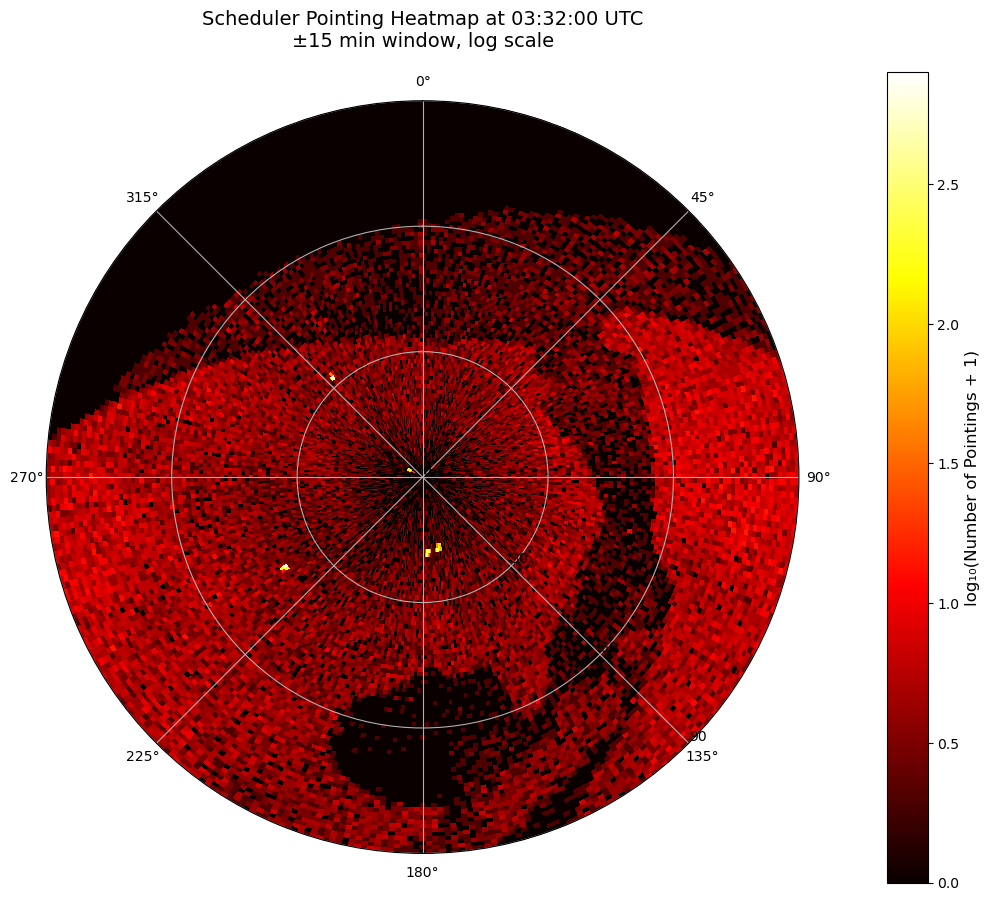


Generating statistics...
✓ Saved scheduler_heatmap_stats.png


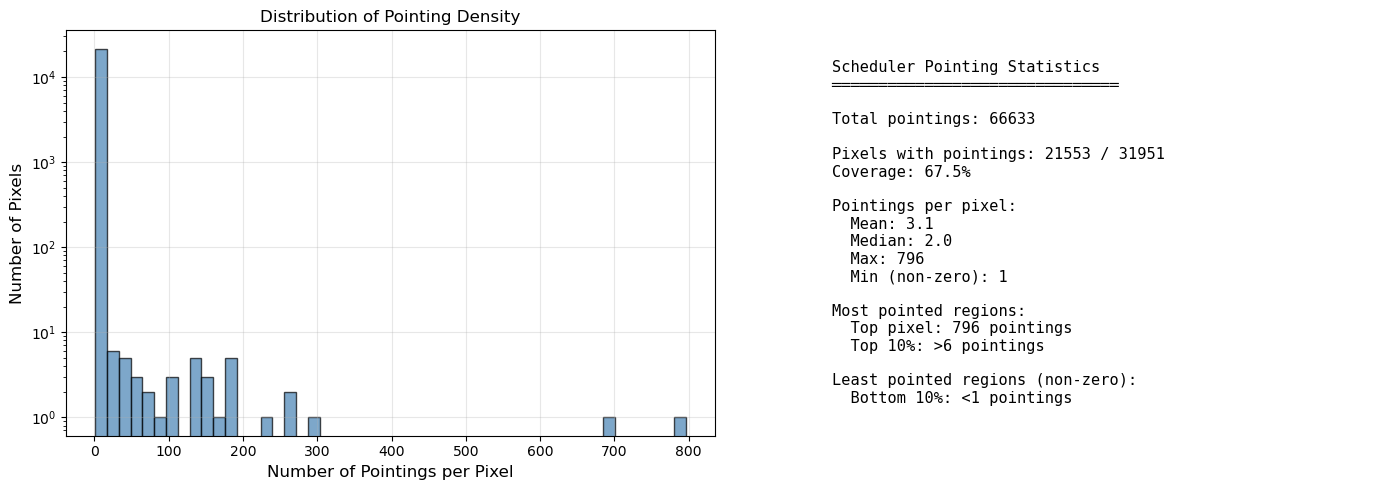


COMPLETE
Output files:
  - scheduler_heatmap_polar.png
  - scheduler_heatmap_stats.png


In [2]:
#!/usr/bin/env python3
"""
Load scheduler pointings from CSV and create heatmap showing
where scheduler points most vs least in polar projection.
"""

import sqlite3
import numpy as np
import pandas as pd
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"

# Target time window
TARGET_TIME_UTC = "03:32:00"  # HH:MM:SS
TIME_WINDOW_MINUTES = 15

NSIDE_HEATMAP = 32  # Resolution for heatmap
NEST = True
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0

# Reference time for projection (any time works)
REFERENCE_TIME = "2025-12-06T03:32:00"

# ---------------- HELPER FUNCTIONS ----------------
def get_time_of_night(mjd_time):
    """Extract time of night in hours."""
    dt = Time(mjd_time, format='mjd').to_datetime()
    return dt.hour + dt.minute / 60.0 + dt.second / 3600.0

def time_difference_minutes(time1_hours, time2_hours):
    """Calculate time difference in minutes, handling midnight wrap."""
    diff = abs(time1_hours - time2_hours)
    if diff > 12:
        diff = 24 - diff
    return diff * 60

def load_scheduler_nights(db_file):
    """Load all scheduler nights and their observations."""
    conn = sqlite3.connect(db_file)
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            break
    
    if table_name is None:
        table_name = tables[0][0]
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    for req in required:
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                break
    
    return obs_df

def radec_to_altaz(ra_deg, dec_deg, obstime):
    """Convert RA/Dec to Alt/Az at given time."""
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=RUBIN_LAT * u.deg,
                             lon=RUBIN_LON * u.deg,
                             height=RUBIN_HEIGHT_M * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def collect_scheduler_pointings(obs_df, target_time_hours, time_window_minutes):
    """Collect all scheduler pointings at target time of night."""
    pointings = []
    
    print(f"Scanning {len(obs_df)} observations...")
    for idx, obs in obs_df.iterrows():
        if idx % 100000 == 0:
            print(f"  Processed {idx}/{len(obs_df)} observations, found {len(pointings)} matches...")
        
        obs_time_hours = get_time_of_night(obs['observationStartMJD'])
        time_diff_min = time_difference_minutes(obs_time_hours, target_time_hours)
        
        if time_diff_min <= time_window_minutes:
            pointings.append((obs['fieldRA'], obs['fieldDec']))
    
    return pointings

def create_altaz_heatmap(pointings, reference_time, nside):
    """Create heatmap of pointings in alt-az space."""
    # Convert all pointings to alt-az
    print(f"Converting {len(pointings)} pointings to alt-az coordinates...")
    
    # Create a grid for binning
    az_bins = np.linspace(0, 360, 360)
    alt_bins = np.linspace(0, 90, 90)
    
    heatmap = np.zeros((len(alt_bins)-1, len(az_bins)-1))
    
    for idx, (ra, dec) in enumerate(pointings):
        if idx % 1000 == 0:
            print(f"  Processing pointing {idx}/{len(pointings)}...")
        
        alt, az = radec_to_altaz(ra, dec, reference_time)
        
        if alt > 0:  # Only count points above horizon
            # Fix: Clamp indices to valid range to avoid IndexError
            az_idx = min(int(az), len(az_bins) - 2)  # Valid range [0, 358]
            alt_idx = min(int(alt), len(alt_bins) - 2)  # Valid range [0, 88]
            heatmap[alt_idx, az_idx] += 1
    
    return heatmap, az_bins, alt_bins

def plot_heatmap_polar(heatmap, az_bins, alt_bins):
    """Plot heatmap in polar projection."""
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Create meshgrid for plotting
    az_centers = (az_bins[:-1] + az_bins[1:]) / 2
    alt_centers = (alt_bins[:-1] + alt_bins[1:]) / 2
    
    Az, Alt = np.meshgrid(np.radians(az_centers), alt_centers)
    R = 90 - Alt
    
    # Plot with log scale for better visualization
    heatmap_log = np.log10(heatmap + 1)  # +1 to avoid log(0)
    
    pcm = ax.pcolormesh(Az, R, heatmap_log, cmap='hot', shading='auto')
    
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rmax(90)
    ax.set_rticks([0, 30, 60, 90])
    ax.set_rlabel_position(135)
    ax.set_title(f'Scheduler Pointing Heatmap at {TARGET_TIME_UTC} UTC\n' + 
                 f'±{TIME_WINDOW_MINUTES} min window, log scale', 
                 fontsize=14, pad=20)
    
    cbar = plt.colorbar(pcm, ax=ax, fraction=0.046, pad=0.1)
    cbar.set_label('log₁₀(Number of Pointings + 1)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('scheduler_heatmap_polar.png', dpi=150, bbox_inches='tight')
    print("✓ Saved scheduler_heatmap_polar.png")
    plt.show()

def plot_heatmap_stats(heatmap):
    """Plot statistics about the heatmap."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of pointing counts
    flat_counts = heatmap.flatten()
    flat_counts = flat_counts[flat_counts > 0]  # Only non-zero
    
    axes[0].hist(flat_counts, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Number of Pointings per Pixel', fontsize=12)
    axes[0].set_ylabel('Number of Pixels', fontsize=12)
    axes[0].set_title('Distribution of Pointing Density', fontsize=12)
    axes[0].set_yscale('log')
    axes[0].grid(alpha=0.3)
    
    # Stats text
    axes[1].axis('off')
    stats_text = f"""
    Scheduler Pointing Statistics
    ═══════════════════════════════
    
    Total pointings: {int(np.sum(heatmap))}
    
    Pixels with pointings: {int(np.sum(heatmap > 0))} / {heatmap.size}
    Coverage: {100 * np.sum(heatmap > 0) / heatmap.size:.1f}%
    
    Pointings per pixel:
      Mean: {np.mean(flat_counts):.1f}
      Median: {np.median(flat_counts):.1f}
      Max: {int(np.max(heatmap))}
      Min (non-zero): {int(np.min(flat_counts))}
      
    Most pointed regions:
      Top pixel: {int(np.max(heatmap))} pointings
      Top 10%: >{int(np.percentile(flat_counts, 90))} pointings
      
    Least pointed regions (non-zero):
      Bottom 10%: <{int(np.percentile(flat_counts, 10))} pointings
    """
    
    axes[1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                verticalalignment='center')
    
    plt.tight_layout()
    plt.savefig('scheduler_heatmap_stats.png', dpi=150, bbox_inches='tight')
    print("✓ Saved scheduler_heatmap_stats.png")
    plt.show()

def main():
    print("="*80)
    print("SCHEDULER POINTING HEATMAP ANALYSIS")
    print("="*80)
    
    # Parse target time
    h, m, s = map(int, TARGET_TIME_UTC.split(':'))
    target_time_hours = h + m/60.0 + s/3600.0
    
    print(f"\nTarget time: {TARGET_TIME_UTC} UTC (±{TIME_WINDOW_MINUTES} minutes)")
    print(f"\nLoading scheduler observations from {DB_FILE}...")
    obs_df = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(obs_df)} observations")
    
    print(f"\nCollecting pointings at target time...")
    pointings = collect_scheduler_pointings(obs_df, target_time_hours, TIME_WINDOW_MINUTES)
    print(f"✓ Found {len(pointings)} pointings at {TARGET_TIME_UTC} UTC")
    
    if len(pointings) == 0:
        print("✗ No pointings found at target time!")
        return
    
    print(f"\nCreating heatmap...")
    reference_time = Time(REFERENCE_TIME, format='isot', scale='utc')
    heatmap, az_bins, alt_bins = create_altaz_heatmap(pointings, reference_time, NSIDE_HEATMAP)
    print(f"✓ Heatmap created")
    
    print(f"\nPlotting heatmap...")
    plot_heatmap_polar(heatmap, az_bins, alt_bins)
    
    print(f"\nGenerating statistics...")
    plot_heatmap_stats(heatmap)
    
    print("\n" + "="*80)
    print("COMPLETE")
    print("Output files:")
    print("  - scheduler_heatmap_polar.png")
    print("  - scheduler_heatmap_stats.png")
    print("="*80)

if __name__ == "__main__":
    main()

SCHEDULER POINTING HEATMAP ANALYSIS

Target time: 23:32:00 UTC (±15 minutes)

Loading scheduler observations from baseline_v5.1.0_10yrs.db...
✓ Loaded 2075536 observations

Scanning 2075536 observations...
  Processed 0/2075536 observations, found 0 matches...
  Processed 100000/2075536 observations, found 1457 matches...
  Processed 200000/2075536 observations, found 4853 matches...
  Processed 300000/2075536 observations, found 5429 matches...
  Processed 400000/2075536 observations, found 9180 matches...
  Processed 500000/2075536 observations, found 9199 matches...
  Processed 600000/2075536 observations, found 12723 matches...


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  Processed 700000/2075536 observations, found 13328 matches...
  Processed 800000/2075536 observations, found 17151 matches...
  Processed 900000/2075536 observations, found 17473 matches...
  Processed 1000000/2075536 observations, found 21377 matches...
  Processed 1100000/2075536 observations, found 21586 matches...
  Processed 1200000/2075536 observations, found 25506 matches...
  Processed 1300000/2075536 observations, found 26063 matches...
  Processed 1400000/2075536 observations, found 28706 matches...
  Processed 1500000/2075536 observations, found 30723 matches...
  Processed 1600000/2075536 observations, found 33667 matches...
  Processed 1700000/2075536 observations, found 34646 matches...
  Processed 1800000/2075536 observations, found 37461 matches...
  Processed 1900000/2075536 observations, found 39103 matches...
  Processed 2000000/2075536 observations, found 41135 matches...
✓ Found 43826 pointings at 23:32:00 UTC

Creating heatmap...
Converting 43826 pointings to al

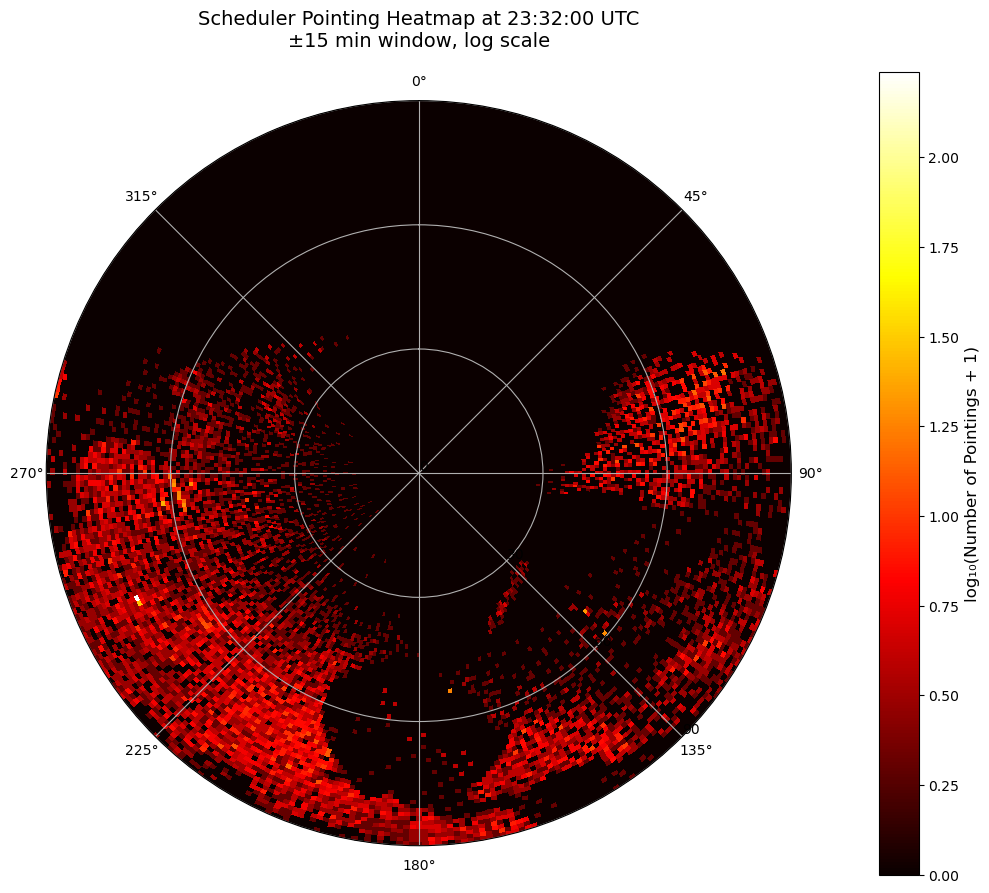


Generating statistics...
✓ Saved scheduler_heatmap_stats.png


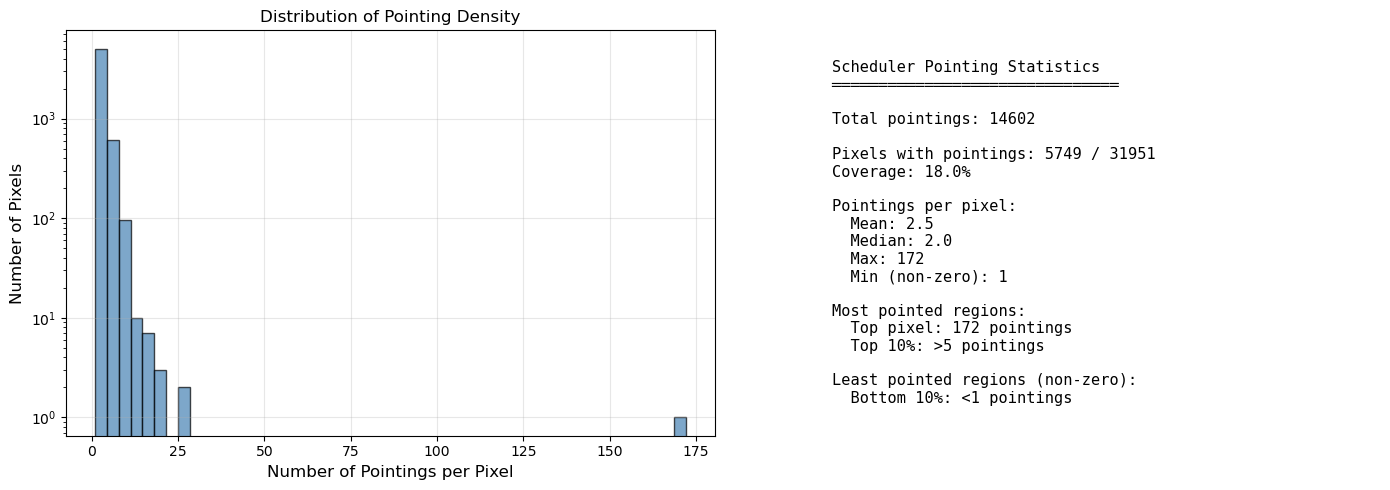


COMPLETE
Output files:
  - scheduler_heatmap_polar.png
  - scheduler_heatmap_stats.png


In [3]:
#!/usr/bin/env python3
"""
Load scheduler pointings from CSV and create heatmap showing
where scheduler points most vs least in polar projection.
"""

import sqlite3
import numpy as np
import pandas as pd
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"

# Target time window
TARGET_TIME_UTC = "23:32:00"  # HH:MM:SS
TIME_WINDOW_MINUTES = 15

NSIDE_HEATMAP = 32  # Resolution for heatmap
NEST = True
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0

# Reference time for projection (any time works)
REFERENCE_TIME = "2025-12-05T23:32:00"

# ---------------- HELPER FUNCTIONS ----------------
def get_time_of_night(mjd_time):
    """Extract time of night in hours."""
    dt = Time(mjd_time, format='mjd').to_datetime()
    return dt.hour + dt.minute / 60.0 + dt.second / 3600.0

def time_difference_minutes(time1_hours, time2_hours):
    """Calculate time difference in minutes, handling midnight wrap."""
    diff = abs(time1_hours - time2_hours)
    if diff > 12:
        diff = 24 - diff
    return diff * 60

def load_scheduler_nights(db_file):
    """Load all scheduler nights and their observations."""
    conn = sqlite3.connect(db_file)
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            break
    
    if table_name is None:
        table_name = tables[0][0]
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    for req in required:
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                break
    
    return obs_df

def radec_to_altaz(ra_deg, dec_deg, obstime):
    """Convert RA/Dec to Alt/Az at given time."""
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=RUBIN_LAT * u.deg,
                             lon=RUBIN_LON * u.deg,
                             height=RUBIN_HEIGHT_M * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def collect_scheduler_pointings(obs_df, target_time_hours, time_window_minutes):
    """Collect all scheduler pointings at target time of night."""
    pointings = []
    
    print(f"Scanning {len(obs_df)} observations...")
    for idx, obs in obs_df.iterrows():
        if idx % 100000 == 0:
            print(f"  Processed {idx}/{len(obs_df)} observations, found {len(pointings)} matches...")
        
        obs_time_hours = get_time_of_night(obs['observationStartMJD'])
        time_diff_min = time_difference_minutes(obs_time_hours, target_time_hours)
        
        if time_diff_min <= time_window_minutes:
            pointings.append((obs['fieldRA'], obs['fieldDec']))
    
    return pointings

def create_altaz_heatmap(pointings, reference_time, nside):
    """Create heatmap of pointings in alt-az space."""
    # Convert all pointings to alt-az
    print(f"Converting {len(pointings)} pointings to alt-az coordinates...")
    
    # Create a grid for binning
    az_bins = np.linspace(0, 360, 360)
    alt_bins = np.linspace(0, 90, 90)
    
    heatmap = np.zeros((len(alt_bins)-1, len(az_bins)-1))
    
    for idx, (ra, dec) in enumerate(pointings):
        if idx % 1000 == 0:
            print(f"  Processing pointing {idx}/{len(pointings)}...")
        
        alt, az = radec_to_altaz(ra, dec, reference_time)
        
        if alt > 0:  # Only count points above horizon
            # Fix: Clamp indices to valid range to avoid IndexError
            az_idx = min(int(az), len(az_bins) - 2)  # Valid range [0, 358]
            alt_idx = min(int(alt), len(alt_bins) - 2)  # Valid range [0, 88]
            heatmap[alt_idx, az_idx] += 1
    
    return heatmap, az_bins, alt_bins

def plot_heatmap_polar(heatmap, az_bins, alt_bins):
    """Plot heatmap in polar projection."""
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Create meshgrid for plotting
    az_centers = (az_bins[:-1] + az_bins[1:]) / 2
    alt_centers = (alt_bins[:-1] + alt_bins[1:]) / 2
    
    Az, Alt = np.meshgrid(np.radians(az_centers), alt_centers)
    R = 90 - Alt
    
    # Plot with log scale for better visualization
    heatmap_log = np.log10(heatmap + 1)  # +1 to avoid log(0)
    
    pcm = ax.pcolormesh(Az, R, heatmap_log, cmap='hot', shading='auto')
    
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rmax(90)
    ax.set_rticks([0, 30, 60, 90])
    ax.set_rlabel_position(135)
    ax.set_title(f'Scheduler Pointing Heatmap at {TARGET_TIME_UTC} UTC\n' + 
                 f'±{TIME_WINDOW_MINUTES} min window, log scale', 
                 fontsize=14, pad=20)
    
    cbar = plt.colorbar(pcm, ax=ax, fraction=0.046, pad=0.1)
    cbar.set_label('log₁₀(Number of Pointings + 1)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig('scheduler_heatmap_polar.png', dpi=150, bbox_inches='tight')
    print("✓ Saved scheduler_heatmap_polar.png")
    plt.show()

def plot_heatmap_stats(heatmap):
    """Plot statistics about the heatmap."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of pointing counts
    flat_counts = heatmap.flatten()
    flat_counts = flat_counts[flat_counts > 0]  # Only non-zero
    
    axes[0].hist(flat_counts, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].set_xlabel('Number of Pointings per Pixel', fontsize=12)
    axes[0].set_ylabel('Number of Pixels', fontsize=12)
    axes[0].set_title('Distribution of Pointing Density', fontsize=12)
    axes[0].set_yscale('log')
    axes[0].grid(alpha=0.3)
    
    # Stats text
    axes[1].axis('off')
    stats_text = f"""
    Scheduler Pointing Statistics
    ═══════════════════════════════
    
    Total pointings: {int(np.sum(heatmap))}
    
    Pixels with pointings: {int(np.sum(heatmap > 0))} / {heatmap.size}
    Coverage: {100 * np.sum(heatmap > 0) / heatmap.size:.1f}%
    
    Pointings per pixel:
      Mean: {np.mean(flat_counts):.1f}
      Median: {np.median(flat_counts):.1f}
      Max: {int(np.max(heatmap))}
      Min (non-zero): {int(np.min(flat_counts))}
      
    Most pointed regions:
      Top pixel: {int(np.max(heatmap))} pointings
      Top 10%: >{int(np.percentile(flat_counts, 90))} pointings
      
    Least pointed regions (non-zero):
      Bottom 10%: <{int(np.percentile(flat_counts, 10))} pointings
    """
    
    axes[1].text(0.1, 0.5, stats_text, fontsize=11, family='monospace',
                verticalalignment='center')
    
    plt.tight_layout()
    plt.savefig('scheduler_heatmap_stats.png', dpi=150, bbox_inches='tight')
    print("✓ Saved scheduler_heatmap_stats.png")
    plt.show()

def main():
    print("="*80)
    print("SCHEDULER POINTING HEATMAP ANALYSIS")
    print("="*80)
    
    # Parse target time
    h, m, s = map(int, TARGET_TIME_UTC.split(':'))
    target_time_hours = h + m/60.0 + s/3600.0
    
    print(f"\nTarget time: {TARGET_TIME_UTC} UTC (±{TIME_WINDOW_MINUTES} minutes)")
    print(f"\nLoading scheduler observations from {DB_FILE}...")
    obs_df = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(obs_df)} observations")
    
    print(f"\nCollecting pointings at target time...")
    pointings = collect_scheduler_pointings(obs_df, target_time_hours, TIME_WINDOW_MINUTES)
    print(f"✓ Found {len(pointings)} pointings at {TARGET_TIME_UTC} UTC")
    
    if len(pointings) == 0:
        print("✗ No pointings found at target time!")
        return
    
    print(f"\nCreating heatmap...")
    reference_time = Time(REFERENCE_TIME, format='isot', scale='utc')
    heatmap, az_bins, alt_bins = create_altaz_heatmap(pointings, reference_time, NSIDE_HEATMAP)
    print(f"✓ Heatmap created")
    
    print(f"\nPlotting heatmap...")
    plot_heatmap_polar(heatmap, az_bins, alt_bins)
    
    print(f"\nGenerating statistics...")
    plot_heatmap_stats(heatmap)
    
    print("\n" + "="*80)
    print("COMPLETE")
    print("Output files:")
    print("  - scheduler_heatmap_polar.png")
    print("  - scheduler_heatmap_stats.png")
    print("="*80)

if __name__ == "__main__":
    main()

In [1]:
#!/usr/bin/env python3
"""
Sampled analysis of scheduler performance vs best sky.

Randomly samples:
- N scheduler nights
- M chronograf nights
- K observations per scheduler night

Generates histograms for each scheduler night sample and an overall histogram.
Target runtime: ~30 minutes
"""

import io
import os
import sqlite3
import numpy as np
import pandas as pd
import h5py
import healpy as hp
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import random

# ---------------- CONFIGURATION ----------------
DB_FILE = "baseline_v5.1.0_10yrs.db"
CHRONOGRAF_CSV = "all_chronograf_data.csv"
OUTPUT_CSV = "sampled_scheduler_analysis.csv"
OUTPUT_DIR = "sampled_histograms"

# Sampling parameters - tune these to hit ~30 min runtime
N_SCHEDULER_NIGHTS = 15  # Sample 20 scheduler nights
N_CHRONOGRAF_NIGHTS = 15  # Sample 15 chronograf nights
N_OBS_PER_NIGHT = 10  # Sample 30 observations per scheduler night

NSIDE_EXPECTED = 32
NEST = True
UNSEEN = hp.UNSEEN if hasattr(hp, "UNSEEN") else np.nan
RUBIN_LAT = -30.244639
RUBIN_LON = -70.749417
RUBIN_HEIGHT_M = 2663.0

# Time matching window (hours)
TIME_WINDOW_HOURS = 0.5

# Random seed for reproducibility
RANDOM_SEED = 42

# ---------------- HELPER FUNCTIONS ----------------
def transform_url(url):
    """Transform https S3 paths to ResourcePath style if needed."""
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url

def fetch_map_resourcepath(url: str):
    """Fetch and read HEALPix cloud map from URL."""
    url = str(url).strip()
    if url.startswith("s3://") or url.startswith("http://") or url.startswith("https://"):
        rp = ResourcePath(url)
        with rp.open("rb") as fd:
            data = fd.read()
        bio = io.BytesIO(data)
    else:
        bio = open(url, "rb")
    
    with h5py.File(bio, "r") as f:
        if "clouds" not in f:
            raise RuntimeError(f"'clouds' dataset not found in {url}")
        arr = np.array(f["clouds"]).ravel()
    
    try:
        bio.close()
    except:
        pass
    
    return arr

def healpix_to_altaz(mp, nside=None, nest=NEST, obstime=None,
                     observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                     observer_height_m=RUBIN_HEIGHT_M):
    """Convert HEALPix map pixels to alt/az arrays."""
    if nside is None:
        nside = hp.get_nside(mp)
    npix = hp.nside2npix(nside)
    pix = np.arange(npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix, nest=nest)
    ra = np.degrees(phi_pix)
    dec = 90.0 - np.degrees(theta_pix)

    if obstime is None:
        obstime = Time.now().utc
    else:
        obstime = Time(obstime) if not isinstance(obstime, Time) else obstime
        obstime = obstime.utc

    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    alt_deg = altaz.alt.deg
    az_deg = altaz.az.deg % 360.0
    vals = np.asarray(mp, dtype=float)
    vals = np.where(vals == UNSEEN, np.nan, vals)
    
    return az_deg, alt_deg, vals

def radec_to_altaz(ra_deg, dec_deg, obstime,
                   observer_lat=RUBIN_LAT, observer_lon=RUBIN_LON,
                   observer_height_m=RUBIN_HEIGHT_M):
    """Convert RA/Dec to Alt/Az at given time."""
    if not isinstance(obstime, Time):
        obstime = Time(obstime)
    obstime = obstime.utc
    
    location = EarthLocation(lat=observer_lat * u.deg,
                             lon=observer_lon * u.deg,
                             height=observer_height_m * u.m)
    sky = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    altaz = sky.transform_to(AltAz(obstime=obstime, location=location))
    
    return altaz.alt.deg, altaz.az.deg % 360.0

def find_best_pointing(mp, nside, obstime):
    """Find the alt/az of pixel with lowest attenuation above horizon."""
    az_deg, alt_deg, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    valid_mask = (alt_deg > 0) & (~np.isnan(vals))
    if not np.any(valid_mask):
        return None, None, None
    
    valid_vals = vals[valid_mask]
    valid_az = az_deg[valid_mask]
    valid_alt = alt_deg[valid_mask]
    
    min_idx = np.nanargmin(valid_vals)
    return valid_az[min_idx], valid_alt[min_idx], valid_vals[min_idx]

def get_attenuation_at_pointing(mp, nside, ra_deg, dec_deg, obstime):
    """Get cloud attenuation value at a specific RA/Dec pointing."""
    actual_alt, actual_az = radec_to_altaz(ra_deg, dec_deg, obstime)
    
    if actual_alt <= 0:
        return None, actual_alt, actual_az
    
    az_arr, alt_arr, vals = healpix_to_altaz(mp, nside, obstime=obstime)
    
    d_az = np.minimum(np.abs(az_arr - actual_az), 360.0 - np.abs(az_arr - actual_az))
    distances = np.sqrt(d_az**2 + (alt_arr - actual_alt)**2)
    
    if np.all(np.isnan(vals)):
        return None, actual_alt, actual_az
    
    nearest_idx = np.nanargmin(distances)
    actual_val = vals[nearest_idx]
    
    if np.isnan(actual_val):
        return None, actual_alt, actual_az
    
    return actual_val, actual_alt, actual_az

def time_match_hours(mjd, datetime_utc):
    """Calculate time difference in hours between MJD and datetime."""
    mjd_time = Time(mjd, format='mjd').to_datetime()
    
    mjd_hour = mjd_time.hour + mjd_time.minute / 60.0 + mjd_time.second / 3600.0
    dt_hour = datetime_utc.hour + datetime_utc.minute / 60.0 + datetime_utc.second / 3600.0
    
    diff = abs(mjd_hour - dt_hour)
    if diff > 12:
        diff = 24 - diff
    
    return diff

# ---------------- DATA LOADING ----------------
def load_scheduler_nights(db_file):
    """Load all scheduler nights and their observations."""
    conn = sqlite3.connect(db_file)
    
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    
    table_name = None
    for possible_name in ['observations', 'SummaryAllProps', 'Summary', 'obs']:
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{possible_name}';")
        if cursor.fetchone():
            table_name = possible_name
            break
    
    if table_name is None:
        table_name = tables[0][0]
    
    obs_df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    conn.close()
    
    night_col = None
    for col in obs_df.columns:
        if 'night' in col.lower():
            night_col = col
            break
    
    if night_col is None:
        raise RuntimeError(f"Could not find 'night' column.")
    
    obs_df['night'] = obs_df[night_col].astype(int)
    
    required = ['observationStartMJD', 'fieldRA', 'fieldDec']
    for req in required:
        found = False
        for col in obs_df.columns:
            if req.lower() in col.lower():
                if col != req:
                    obs_df[req] = obs_df[col]
                found = True
                break
    
    scheduler_nights = {}
    for night in obs_df['night'].unique():
        night_obs = obs_df[obs_df['night'] == night].copy()
        scheduler_nights[int(night)] = night_obs
    
    return scheduler_nights

def load_chronograf_nights(csv_file):
    """Load all chronograf nights and their cloud maps."""
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', '').str.strip()
    
    url_cols = [c for c in df.columns if c.lower() not in ['time', 'timestamp']]
    if len(url_cols) == 0:
        raise RuntimeError("No URL column found in chronograf CSV.")
    url_col = url_cols[0]
    
    df = df.dropna(subset=[url_col]).copy()
    df['time'] = pd.to_datetime(df['time'], errors='coerce', utc=True)
    df = df.dropna(subset=['time']).copy()
    
    if df['time'].dt.tz is None:
        df['time'] = df['time'].dt.tz_localize('UTC')
    else:
        df['time'] = df['time'].dt.tz_convert('UTC')
    
    df[url_col] = df[url_col].astype(str).str.strip().apply(transform_url)
    
    # Filter to HDF5 cloud_sys files only
    df = df[df[url_col].str.contains('.hdf5', case=False, na=False)].copy()
    df = df[df[url_col].str.contains('cloud_sys', case=False, na=False)].copy()
    
    df['date'] = df['time'].dt.date
    chronograf_nights = {}
    
    for date in df['date'].unique():
        date_df = df[df['date'] == date].sort_values('time').reset_index(drop=True)
        chronograf_nights[date] = date_df
    
    return chronograf_nights

# ---------------- MAIN ANALYSIS ----------------
def analyze_sampled():
    """Analyze sampled scheduler and chronograf nights."""
    
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    
    # Create output directory
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    print("="*80)
    print("SAMPLED SCHEDULER ANALYSIS")
    print("="*80)
    print(f"Configuration:")
    print(f"  Scheduler nights to sample: {N_SCHEDULER_NIGHTS}")
    print(f"  Chronograf nights to sample: {N_CHRONOGRAF_NIGHTS}")
    print(f"  Observations per scheduler night: {N_OBS_PER_NIGHT}")
    print(f"  Time window: {TIME_WINDOW_HOURS} hours")
    print(f"  Random seed: {RANDOM_SEED}")
    
    print(f"\nLoading scheduler nights from {DB_FILE}...")
    scheduler_nights = load_scheduler_nights(DB_FILE)
    print(f"✓ Loaded {len(scheduler_nights)} scheduler nights")
    
    print(f"\nLoading chronograf nights from {CHRONOGRAF_CSV}...")
    chronograf_nights = load_chronograf_nights(CHRONOGRAF_CSV)
    print(f"✓ Loaded {len(chronograf_nights)} chronograf nights")
    
    # Sample nights
    print(f"\nSampling nights...")
    sampled_sched_nights = random.sample(list(scheduler_nights.keys()), 
                                         min(N_SCHEDULER_NIGHTS, len(scheduler_nights)))
    sampled_chron_nights = random.sample(list(chronograf_nights.keys()),
                                         min(N_CHRONOGRAF_NIGHTS, len(chronograf_nights)))
    
    print(f"✓ Sampled {len(sampled_sched_nights)} scheduler nights")
    print(f"✓ Sampled {len(sampled_chron_nights)} chronograf nights")
    
    total_combinations = len(sampled_sched_nights) * len(sampled_chron_nights)
    print(f"\nTotal combinations to analyze: {total_combinations}")
    print(f"{'='*80}\n")
    
    all_results = []
    night_results = {}  # Store results per scheduler night for individual histograms
    combo_count = 0
    
    for sched_night in sorted(sampled_sched_nights):
        sched_obs = scheduler_nights[sched_night]
        night_results[sched_night] = []
        
        # Sample observations from this night
        if len(sched_obs) > N_OBS_PER_NIGHT:
            sampled_indices = random.sample(range(len(sched_obs)), N_OBS_PER_NIGHT)
            sched_obs_sample = sched_obs.iloc[sampled_indices]
        else:
            sched_obs_sample = sched_obs
        
        for chron_date in sorted(sampled_chron_nights):
            combo_count += 1
            chron_df = chronograf_nights[chron_date]
            
            print(f"[{combo_count}/{total_combinations}] Night {sched_night} vs {chron_date}")
            print(f"  Observations: {len(sched_obs_sample)}, Maps: {len(chron_df)}")
            
            matches = 0
            for idx, chron_row in chron_df.iterrows():
                try:
                    cloud_map = fetch_map_resourcepath(chron_row[chron_df.columns[1]])
                    map_time = chron_row['time'].to_pydatetime()
                except Exception as e:
                    continue
                
                try:
                    best_az, best_alt, best_atten = find_best_pointing(
                        cloud_map, NSIDE_EXPECTED, map_time)
                except Exception as e:
                    continue
                
                if best_atten is None:
                    continue
                
                for _, obs in sched_obs_sample.iterrows():
                    try:
                        time_diff = time_match_hours(obs['observationStartMJD'], map_time)
                        
                        if time_diff <= TIME_WINDOW_HOURS:
                            actual_atten, actual_alt, actual_az = get_attenuation_at_pointing(
                                cloud_map, NSIDE_EXPECTED,
                                obs['fieldRA'], obs['fieldDec'], map_time)
                            
                            if actual_atten is not None:
                                matches += 1
                                difference = actual_atten - best_atten
                                
                                result = {
                                    'scheduler_night': sched_night,
                                    'chronograf_date': str(chron_date),
                                    'map_time_utc': map_time.isoformat(),
                                    'obs_mjd': obs['observationStartMJD'],
                                    'time_diff_hours': time_diff,
                                    'best_attenuation': best_atten,
                                    'best_az': best_az,
                                    'best_alt': best_alt,
                                    'actual_attenuation': actual_atten,
                                    'actual_az': actual_az,
                                    'actual_alt': actual_alt,
                                    'difference': difference,
                                    'obs_ra': obs['fieldRA'],
                                    'obs_dec': obs['fieldDec']
                                }
                                
                                all_results.append(result)
                                night_results[sched_night].append(result)
                    except Exception as e:
                        continue
            
            print(f"  ✓ Found {matches} matches")
    
    print(f"\n{'='*80}")
    print("ANALYSIS COMPLETE")
    print(f"{'='*80}")
    
    if len(all_results) == 0:
        print("\n✗ No matches found")
        return
    
    # Save all results
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(OUTPUT_CSV, index=False)
    
    print(f"\n✓ Results saved to {OUTPUT_CSV}")
    print(f"✓ Total matches: {len(results_df)}")
    
    # Overall statistics
    print(f"\nOverall Statistics:")
    print(f"  Mean difference: {results_df['difference'].mean():.4f} mag")
    print(f"  Median difference: {results_df['difference'].median():.4f} mag")
    print(f"  Std difference: {results_df['difference'].std():.4f} mag")
    print(f"  Min difference: {results_df['difference'].min():.4f} mag")
    print(f"  Max difference: {results_df['difference'].max():.4f} mag")
    print(f"  % worse than best (diff > 0.05): {(results_df['difference'] > 0.05).sum() / len(results_df) * 100:.1f}%")
    
    # Generate overall histogram
    print(f"\nGenerating overall histogram...")
    plt.figure(figsize=(12, 7))
    plt.hist(results_df['difference'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Optimal (diff=0)')
    plt.xlabel('Difference from Best (mag)', fontsize=12)
    plt.ylabel('Number of Observations', fontsize=12)
    plt.title(f'Sampled Scheduler Performance: Actual vs Best Pointing\nN={len(results_df)} matches from {N_SCHEDULER_NIGHTS} nights', fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    overall_hist = os.path.join(OUTPUT_DIR, 'overall_histogram.png')
    plt.savefig(overall_hist, dpi=150)
    print(f"✓ Overall histogram saved to {overall_hist}")
    plt.close()
    
    # Generate per-night histograms
    print(f"\nGenerating per-night histograms...")
    for night, results in night_results.items():
        if len(results) == 0:
            continue
        
        night_df = pd.DataFrame(results)
        
        plt.figure(figsize=(10, 6))
        plt.hist(night_df['difference'], bins=30, edgecolor='black', alpha=0.7, color='coral')
        plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Optimal')
        plt.xlabel('Difference from Best (mag)', fontsize=11)
        plt.ylabel('Count', fontsize=11)
        plt.title(f'Night {night}: N={len(night_df)} matches\nMean={night_df["difference"].mean():.4f}, Median={night_df["difference"].median():.4f}', fontsize=12)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        night_hist = os.path.join(OUTPUT_DIR, f'night_{night}_histogram.png')
        plt.savefig(night_hist, dpi=150)
        plt.close()
    
    print(f"✓ Generated {len([n for n in night_results if len(night_results[n]) > 0])} night histograms")
    
    # Summary by night
    print(f"\nPer-Night Summary:")
    for night in sorted(night_results.keys()):
        if len(night_results[night]) > 0:
            night_df = pd.DataFrame(night_results[night])
            print(f"  Night {night}: {len(night_df)} matches, "
                  f"mean={night_df['difference'].mean():.4f}, "
                  f"median={night_df['difference'].median():.4f}")
    
    print(f"\n✓ All outputs saved to {OUTPUT_DIR}/")

if __name__ == "__main__":
    analyze_sampled()

SAMPLED SCHEDULER ANALYSIS
Configuration:
  Scheduler nights to sample: 15
  Chronograf nights to sample: 15
  Observations per scheduler night: 10
  Time window: 0.5 hours
  Random seed: 42

Loading scheduler nights from baseline_v5.1.0_10yrs.db...
✓ Loaded 2771 scheduler nights

Loading chronograf nights from all_chronograf_data.csv...
✓ Loaded 146 chronograf nights

Sampling nights...
✓ Sampled 15 scheduler nights
✓ Sampled 15 chronograf nights

Total combinations to analyze: 225

[1/225] Night 131 vs 2025-06-26
  Observations: 10, Maps: 167
  ✓ Found 0 matches
[2/225] Night 131 vs 2025-07-01
  Observations: 10, Maps: 1390
  ✓ Found 0 matches
[3/225] Night 131 vs 2025-08-13
  Observations: 10, Maps: 1302
  ✓ Found 0 matches
[4/225] Night 131 vs 2025-08-26
  Observations: 10, Maps: 1266
  ✓ Found 0 matches
[5/225] Night 131 vs 2025-09-02
  Observations: 10, Maps: 1245
  ✓ Found 0 matches
[6/225] Night 131 vs 2025-09-03
  Observations: 10, Maps: 1241
  ✓ Found 0 matches
[7/225] Night 

/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  ✓ Found 0 matches
[122/225] Night 1176 vs 2025-07-01
  Observations: 10, Maps: 1390


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  ✓ Found 0 matches
[123/225] Night 1176 vs 2025-08-13
  Observations: 10, Maps: 1302


...

  ✓ Found 0 matches
[224/225] Night 3441 vs 2025-12-08
  Observations: 10, Maps: 937


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  ✓ Found 0 matches
[225/225] Night 3441 vs 2025-12-12
  Observations: 10, Maps: 933


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  ✓ Found 11 matches

ANALYSIS COMPLETE

✓ Results saved to sampled_scheduler_analysis.csv
✓ Total matches: 77786

Overall Statistics:
  Mean difference: 1.6382 mag
  Median difference: 0.8446 mag
  Std difference: 1.3294 mag
  Min difference: 0.0000 mag
  Max difference: 12.4945 mag
  % worse than best (diff > 0.05): 100.0%

Generating overall histogram...
✓ Overall histogram saved to sampled_histograms/overall_histogram.png

Generating per-night histograms...
✓ Generated 15 night histograms

Per-Night Summary:
  Night 131: 597 matches, mean=1.0468, median=0.5940
  Night 155: 963 matches, mean=1.9149, median=2.1605
  Night 165: 890 matches, mean=1.0552, median=0.5944
  Night 464: 2796 matches, mean=1.6871, median=0.9489
  Night 492: 1433 matches, mean=1.9826, median=1.8541
  Night 532: 625 matches, mean=2.3336, median=0.7176
  Night 577: 7553 matches, mean=1.9902, median=1.9928
  Night 734: 12577 matches, mean=1.5366, median=0.7764
  Night 1176: 12446 matches, mean=1.5204, median=0.74